<a href="https://colab.research.google.com/github/YaroslavTrusov/python-ai-template-Yaroslav_Trusov/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

## 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий курса в Google Colab
- Загружаем CSV-файл `planes.csv`, `engines.csv`, `engine_manufacturers.csv`
- Очищаем столбцы: переименовываем URL Wikidata в `URL`, переименовываем `*Label` → короткие имена


In [1]:
# 🐱 Шаг 1. Клонируем репозиторий в Colab

import os
import pandas as pd
from IPython.display import display

repo = "python-ai-template-Yaroslav_Trusov"
repo_path = f"/content/{repo}"  # абсолютный путь — не зависит от cwd

if not os.path.exists(repo_path):          # всегда проверяет /content/python-ai-template
    !git clone -q https://github.com/YaroslavTrusov/python-ai-template-Yaroslav_Trusov

if os.getcwd() != repo_path:               # точное сравнение, не endswith
    %cd {repo_path}

print("✅ Репозиторий готов, теперь мы работаем внутри папки", repo)

# Шаг 2: Загружаем CSV-файлы
df_planes = pd.read_csv("data/planes.csv")
df_engines = pd.read_csv("data/engines.csv")
df_engine_manufacturers = pd.read_csv("data/engine_manufacturers.csv")
print(f"📊 Загружено строк в df_planes (самолеты): {len(df_planes)}")
print(f"📊 Загружено строк в df_engines (двигатели): {len(df_engines)}\n")
print(f"📊 Загружено строк в df_engine_manufacturers (производители самолетов): {len(df_engine_manufacturers)}")

# 🧹 ШАГ 3: Очистка и переименование столбцов

# ============================================================================
# 1️⃣ df_planes: Самолёты
# ============================================================================
print("=" * 60)
print("✈️ Обработка df_planes (самолёты)")
print("=" * 60)

# Переименование столбцов (с проверкой наличия)
if "aircraftLabel" in df_planes.columns:
    df_planes = df_planes.rename(columns={
        "aircraft": "aircraftURL",
        "aircraftLabel": "aircraft",
        "engine": "engineURL",
        "engineLabel": "engine",
        "maxAltitude": "altitude",
        "totalProduced": "produced",
    })
    print("✅ Столбцы переименованы")
else:
    print("⏭️ Столбцы уже переименованы, пропускаем")

# Проверка заполненности ДО очистки (OPTIONAL-поля)
print("\n📊 Заполненность данных ДО очистки:")
optional_planes = ["price", "altitude", "produced"]
for col in optional_planes:
    if col in df_planes.columns:
        fill_rate = df_planes[col].notna().mean()
        status = "⚠️ НИЗКАЯ" if fill_rate < 0.15 else "✅"
        print(f"   {status} {col:12s}: {fill_rate:6.2%} ({df_planes[col].notna().sum()} из {len(df_planes)})")

# 🔧 Очистка числовых полей (ИСПРАВЛЕНИЕ: прямой astype на Series)
print("\n🔧 Очистка числовых полей:")
for col in ["altitude", "price", "produced"]:
    if col in df_planes.columns:
        if df_planes[col].dtype not in ['Int64', 'int64']:
            # 🔧 ИСПРАВЛЕНИЕ: convert_dtypes() автоматически выбирает Int64
            df_planes[col] = pd.to_numeric(df_planes[col], errors="coerce").convert_dtypes()
            print(f"   ✅ {col:12s}: преобразован в {df_planes[col].dtype} (NaN сохранён)")
        else:
            print(f"   ⏭️ {col:12s}: уже числовой, пропускаем")

# Проверка заполненности ПОСЛЕ очистки
print("\n📊 Заполненность данных ПОСЛЕ очистки:")
for col in optional_planes:
    if col in df_planes.columns:
        fill_rate = df_planes[col].notna().mean()
        print(f"   {col:12s}: {fill_rate:6.2%}")

# Документирование «длинного формата»
print(f"\n📏 Структура данных:")
print(f"   Уникальных самолётов (aircraftURL): {df_planes['aircraftURL'].nunique()}")
print(f"   Всего строк: {len(df_planes)}")
print(f"   → Среднее строк на самолёт: {len(df_planes)/df_planes['aircraftURL'].nunique():.2f}")
if len(df_planes) > df_planes['aircraftURL'].nunique() * 1.5:
    print("   ⚠️ Данные в «длинном формате» — один самолёт имеет несколько записей")


# ============================================================================
# 2️⃣ df_engines: Двигатели
# ============================================================================
print("\n" + "=" * 60)
print("🔧 Обработка df_engines (двигатели)")
print("=" * 60)

# Переименование столбцов
if "engineLabel" in df_engines.columns:
    df_engines = df_engines.rename(columns={
        "engine": "engineURL",
        "engineLabel": "engine",
        "manufacturer": "manufacturerURL",
        "manufacturerLabel": "manufacturer",
    })
    print("✅ Столбцы переименованы")
else:
    print("⏭️ Столбцы уже переименованы, пропускаем")

# Проверка заполненности ДО очистки
print("\n📊 Заполненность данных ДО очистки:")
optional_engines = ["cylinders", "cooling", "power"]
for col in optional_engines:
    if col in df_engines.columns:
        fill_rate = df_engines[col].notna().mean()
        status = "⚠️ НИЗКАЯ" if fill_rate < 0.15 else "✅"
        print(f"   {status} {col:12s}: {fill_rate:6.2%} ({df_engines[col].notna().sum()} из {len(df_engines)})")

# 🔧 Очистка числовых полей (ИСПРАВЛЕНИЕ)
print("\n🔧 Очистка числовых полей:")
for col in ["cylinders", "power"]:
    if col in df_engines.columns:
        if df_engines[col].dtype not in ['Int64', 'int64']:
            df_engines[col] = pd.to_numeric(df_engines[col], errors="coerce").convert_dtypes()
            print(f"   ✅ {col:12s}: преобразован в {df_engines[col].dtype} (NaN сохранён)")
        else:
            print(f"   ⏭️ {col:12s}: уже числовой, пропускаем")

# Строковые поля (cooling) — привести к нижнему регистру
if "cooling" in df_engines.columns:
    df_engines["cooling"] = df_engines["cooling"].str.lower().str.strip()
    print("   ✅ cooling: приведён к нижнему регистру")

# Проверка заполненности ПОСЛЕ очистки
print("\n📊 Заполненность данных ПОСЛЕ очистки:")
for col in optional_engines:
    if col in df_engines.columns:
        fill_rate = df_engines[col].notna().mean()
        print(f"   {col:12s}: {fill_rate:6.2%}")

# Документирование структуры
print(f"\n📏 Структура данных:")
print(f"   Уникальных двигателей (engineURL): {df_engines['engineURL'].nunique()}")
print(f"   Всего строк: {len(df_engines)}")
print(f"   → Среднее строк на двигатель: {len(df_engines)/df_engines['engineURL'].nunique():.2f}")


# ============================================================================
# 3️⃣ df_engine_manufacturers: Производители двигателей
# ============================================================================
print("\n" + "=" * 60)
print("🏭 Обработка df_engine_manufacturers (производители)")
print("=" * 60)

# Переименование столбцов
if "manufacturerLabel" in df_engine_manufacturers.columns:
    df_engine_manufacturers = df_engine_manufacturers.rename(columns={
        "manufacturer": "manufacturerURL",
        "manufacturerLabel": "manufacturer",
        "countryLabel": "country",
        "headquartersLabel": "headquarters",
    })
    print("✅ Столбцы переименованы")
else:
    print("⏭️ Столбцы уже переименованы, пропускаем")

# Проверка заполненности ДО очистки
print("\n📊 Заполненность данных ДО очистки:")
optional_mfr = ["country", "headquarters", "coordinates", "founded"]
for col in optional_mfr:
    if col in df_engine_manufacturers.columns:
        fill_rate = df_engine_manufacturers[col].notna().mean()
        status = "⚠️ НИЗКАЯ" if fill_rate < 0.15 else "✅"
        print(f"   {status} {col:15s}: {fill_rate:6.2%} ({df_engine_manufacturers[col].notna().sum()} из {len(df_engine_manufacturers)})")

# 🔧 Очистка числовых полей (ИСПРАВЛЕНИЕ)
print("\n🔧 Очистка числовых полей:")
for col in ["founded"]:
    if col in df_engine_manufacturers.columns:
        if df_engine_manufacturers[col].dtype not in ['Int64', 'int64']:
            df_engine_manufacturers[col] = pd.to_numeric(df_engine_manufacturers[col], errors="coerce").convert_dtypes()
            print(f"   ✅ {col:15s}: преобразован в {df_engine_manufacturers[col].dtype} (NaN сохранён)")
        else:
            print(f"   ⏭️ {col:15s}: уже числовой, пропускаем")

# Строковые поля — привести к нижнему регистру
for col in ["country", "headquarters"]:
    if col in df_engine_manufacturers.columns:
        df_engine_manufacturers[col] = df_engine_manufacturers[col].str.lower().str.strip()
        print(f"   ✅ {col:15s}: приведён к нижнему регистру")

# Проверка заполненности ПОСЛЕ очистки
print("\n📊 Заполненность данных ПОСЛЕ очистки:")
for col in optional_mfr:
    if col in df_engine_manufacturers.columns:
        fill_rate = df_engine_manufacturers[col].notna().mean()
        print(f"   {col:15s}: {fill_rate:6.2%}")

# Документирование структуры
print(f"\n📏 Структура данных:")
print(f"   Уникальных производителей (manufacturerURL): {df_engine_manufacturers['manufacturerURL'].nunique()}")
print(f"   Всего строк: {len(df_engine_manufacturers)}")
print(f"   → Среднее строк на производителя: {len(df_engine_manufacturers)/df_engine_manufacturers['manufacturerURL'].nunique():.2f}")


# ============================================================================
# 📋 ИТОГОВАЯ ПРОВЕРКА
# ============================================================================
print("\n" + "=" * 60)
print("✅ ИТОГОВАЯ ПРОВЕРКА ВСЕХ ДАТАФРЕЙМОВ")
print("=" * 60)

summary_data = [
    ("df_planes", df_planes),
    ("df_engines", df_engines),
    ("df_engine_manufacturers", df_engine_manufacturers)
]

for df_name, df in summary_data:
    print(f"\n{df_name}:")
    print(f"   📊 Размер: {df.shape[0]:,} строк × {df.shape[1]} столбцов")
    url_cols = [c for c in df.columns if 'URL' in c]
    print(f"   🔑 URL-столбец: {url_cols[0] if url_cols else 'Не найден'}")
    print(f"   📋 Столбцы: {list(df.columns)}")

# Краткий обзор датасетов
def show_info(df, name, n=5):
    """Краткий обзор DataFrame: имя, размер, список столбцов и первые строки."""
    print(f"\n📊 {name}")
    print("Размер:", df.shape)
    print("Столбцы:", ", ".join(df.columns))
    print("\nПервые строки:")
    print(df.head(n))

# 🔍 Шаг 3. Обзор данных

show_info(df_planes, "Виды самолетов, двигателей, цена, максимальная высота и суммарное количество, произведенных самолетов (df_planes)")
print(df_planes[['altitude', 'price', 'produced']].describe())
show_info(df_engines, "Виды двигателей, используемых в самолётах, с обязательным производителем и страной (df_engines)")
print(df_engines[['cylinders']].describe())
show_info(df_engine_manufacturers, "Производители двигателей, используемых в самолётах, с метками страны и штаб-квартиры (df_engine_manufacturers)")

/content/python-ai-template-Yaroslav_Trusov
✅ Репозиторий готов, теперь мы работаем внутри папки python-ai-template-Yaroslav_Trusov
📊 Загружено строк в df_planes (самолеты): 1109
📊 Загружено строк в df_engines (двигатели): 1224

📊 Загружено строк в df_engine_manufacturers (производители самолетов): 309
✈️ Обработка df_planes (самолёты)
✅ Столбцы переименованы

📊 Заполненность данных ДО очистки:
   ⚠️ НИЗКАЯ price       :  2.52% (28 из 1109)
   ✅ altitude    : 45.72% (507 из 1109)
   ✅ produced    : 100.00% (1109 из 1109)

🔧 Очистка числовых полей:
   ✅ altitude    : преобразован в Float64 (NaN сохранён)
   ✅ price       : преобразован в Int64 (NaN сохранён)
   ⏭️ produced    : уже числовой, пропускаем

📊 Заполненность данных ПОСЛЕ очистки:
   price       :  2.52%
   altitude    : 45.72%
   produced    : 100.00%

📏 Структура данных:
   Уникальных самолётов (aircraftURL): 522
   Всего строк: 1109
   → Среднее строк на самолёт: 2.12
   ⚠️ Данные в «длинном формате» — один самолёт имеет не

In [2]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей для красивых графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

# Данные уже загружены и обработаны в ноутбуке
# Используем существующие df_planes, df_engines, df_engine_manufacturers

print("=" * 80)
print("🚀 ГЛУБОКИЙ АНАЛИЗ ДАННЫХ О САМОЛЕТАХ И ДВИГАТЕЛЯХ")
print("=" * 80)

🚀 ГЛУБОКИЙ АНАЛИЗ ДАННЫХ О САМОЛЕТАХ И ДВИГАТЕЛЯХ


## [1] Bar + Line Chart: The evolution of the aircraft industry

**Что показывает:** Эволюцию авиастроения (пик производства — Вторая мировая война, пик новых моделей — 1950-60-е (эпоха реактивной авиации)).

ЭВОЛЮЦИЯ АВИАСТРОЕНИЯ: Производство и новые модели (1930-2000)

📋 Всего записей с данными о производстве: 1048
📋 Диапазон лет в данных: 1903 - 2024
📋 После фильтрации (1930-2000): 67 лет


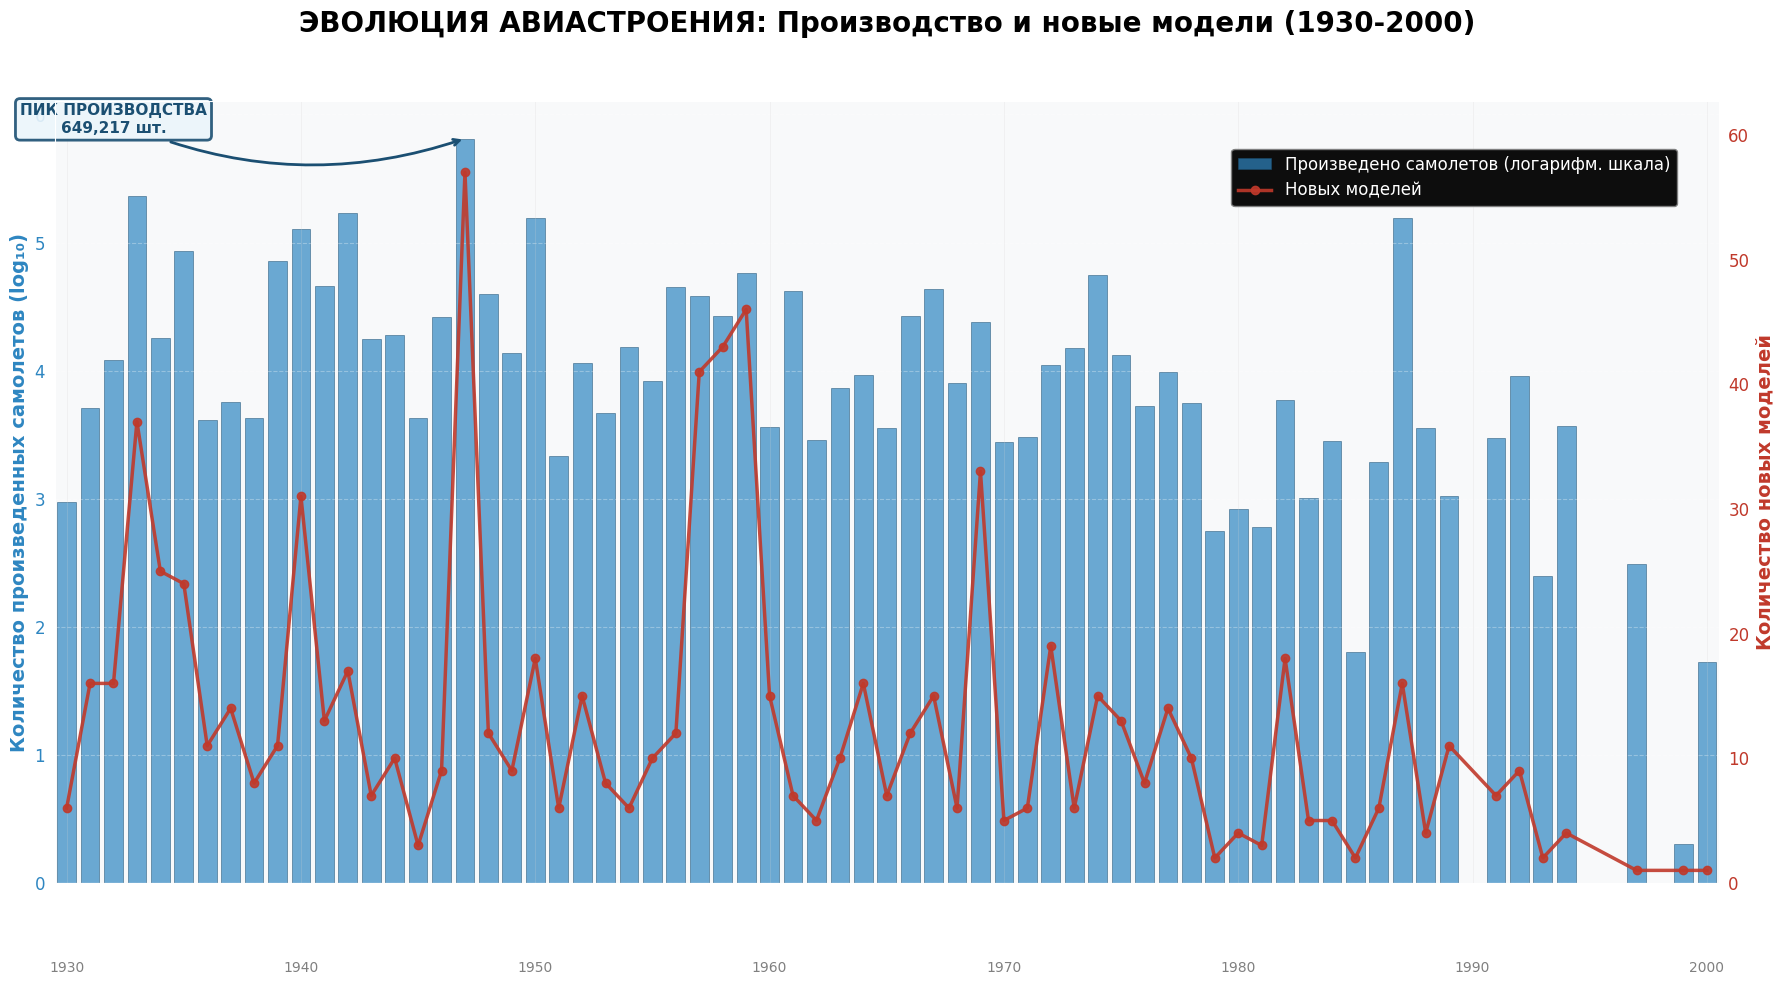


📋 ПРОВЕРКА СООТВЕТСТВИЯ ГОДОВ И ДАННЫХ

🔍 Пик производства:
   • Год: 1947
   • Производство: 649,217 шт.
   • Столбец находится точно над годом 1947

🔍 Пик новых моделей:
   • Год: 1947
   • Новых моделей: 57
   • Точка на линии находится точно над годом 1947
   • Верхняя граница оси Y: 62.7 (пик 57 внутри)

📅 Крайние годы в данных:
   • Первый год: 1930
   • Последний год: 2000

📊 СТАТИСТИЧЕСКИЙ АНАЛИЗ ДИНАМИКИ

📈 ОБЩАЯ СТАТИСТИКА ЗА ПЕРИОД 1930-2000:
   • Всего произведено самолетов: 2,398,003 шт.
   • В среднем в год: 35,791 шт.
   • Всего новых моделей: 864
   • В среднем новых моделей в год: 12.9

🏆 ПИКОВЫЕ ЗНАЧЕНИЯ:
   • Максимальное производство: 649,217 шт. в 1947 году
   • Максимум новых моделей: 57 в 1947 году

📅 АНАЛИЗ ПО ДЕСЯТИЛЕТИЯМ:

   1930-е годы:
      • Произведено: 437,497 шт. (в среднем 43,750 в год)
      • Новых моделей: 168 (в среднем 16.8 в год)

   1940-е годы:
      • Произведено: 1,114,087 шт. (в среднем 111,409 в год)
      • Новых моделей: 168 (в среднем 

In [35]:
# ============================================================================
# КОМБИНИРОВАННЫЙ ГРАФИК (BAR + LINE) - ЭВОЛЮЦИЯ ПРОИЗВОДСТВА ПО ГОДАМ
# ============================================================================
# Показывает динамику авиастроения: производство (столбцы) и новые модели (линия)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ЭВОЛЮЦИЯ АВИАСТРОЕНИЯ: Производство и новые модели (1930-2000)")
print("="*80)

# ============================================================================
# ШАГ 1: ПОДГОТОВКА ДАННЫХ
# ============================================================================

df_planes_years = df_planes.copy()
df_planes_years['year'] = pd.to_datetime(df_planes['firstFlight'], errors='coerce').dt.year
df_planes_years = df_planes_years.dropna(subset=['year', 'produced'])
df_planes_years['year'] = df_planes_years['year'].astype(int)

print(f"\n📋 Всего записей с данными о производстве: {len(df_planes_years)}")

# Группируем по годам
yearly_production = df_planes_years.groupby('year').agg({
    'produced': 'sum',
    'aircraft': 'count'
}).reset_index()

print(f"📋 Диапазон лет в данных: {yearly_production['year'].min()} - {yearly_production['year'].max()}")

# Фильтруем годы с 1930 по 2000 для лучшей читаемости
yearly_production = yearly_production[
    (yearly_production['year'] >= 1930) &
    (yearly_production['year'] <= 2000)
].copy()

print(f"📋 После фильтрации (1930-2000): {len(yearly_production)} лет")

# ============================================================================
# ШАГ 2: ЛОГАРИФМИРОВАНИЕ ПРОИЗВОДСТВА
# ============================================================================

# Используем логарифмическую шкалу для лучшей визуализации
use_log_scale = True

if use_log_scale:
    yearly_production['log_produced'] = np.log10(yearly_production['produced'] + 1)
    production_col = 'log_produced'
    ylabel_left = 'Количество произведенных самолетов (log₁₀)'
else:
    production_col = 'produced'
    ylabel_left = 'Количество произведенных самолетов'

# ============================================================================
# ШАГ 3: СОЗДАНИЕ КОМБИНИРОВАННОГО ГРАФИКА
# ============================================================================

# Создаем фигуру с улучшенным дизайном
fig, ax1 = plt.subplots(figsize=(18, 10))
fig.patch.set_facecolor('white')
ax1.set_facecolor('#f8f9fa')

# Устанавливаем точные границы по оси X (убираем отступы)
ax1.set_xlim(1929.5, 2000.5)

# Bar chart для количества произведенных самолетов
bars = ax1.bar(
    yearly_production['year'],
    yearly_production[production_col],
    alpha=0.7,
    color='#2E86C1',
    edgecolor='#1B4F72',
    linewidth=0.5,
    width=0.8,
    label='Произведено самолетов (логарифм. шкала)'
)

# Настройка левой оси (производство)
ax1.set_xlabel('Год первого полета', fontsize=14, fontweight='bold', labelpad=10)
ax1.set_ylabel(ylabel_left, fontsize=14, fontweight='bold', color='#2E86C1')
ax1.tick_params(axis='y', labelcolor='#2E86C1')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, linestyle='--', axis='y')

# Line chart для количества новых моделей - сдвигаем линию вниз, чтобы не выходила за пределы
max_models = yearly_production['aircraft'].max()
# Устанавливаем верхнюю границу правой оси с небольшим запасом, но чтобы пик был в пределах графика
ax2 = ax1.twinx()
ax2.set_ylim(0, max_models * 1.1)  # Добавляем 10% запаса сверху, но пик остается внутри

line = ax2.plot(
    yearly_production['year'],
    yearly_production['aircraft'],
    color='#C0392B',
    marker='o',
    markersize=6,
    linewidth=2.5,
    label='Новых моделей',
    alpha=0.9
)

# Настройка правой оси (новые модели)
ax2.set_ylabel('Количество новых моделей', fontsize=14, fontweight='bold', color='#C0392B')
ax2.tick_params(axis='y', labelcolor='#C0392B')
ax2.grid(False)

# Добавляем годы снизу графика (каждое десятилетие)
for year in range(1930, 2001, 10):
    ax1.axvline(x=year, color='lightgray', linestyle='-', alpha=0.3, linewidth=0.5)
    ax1.text(year, -0.1, str(year), transform=ax1.get_xaxis_transform(),
            ha='center', va='top', fontsize=10, color='gray')

# ============================================================================
# ШАГ 4: АННОТАЦИЯ ДЛЯ ПИКА ПРОИЗВОДСТВА
# ============================================================================

# Аннотация для пика производства (слева под заголовком)
peak_prod_idx = yearly_production['produced'].idxmax()
peak_prod_year = yearly_production.loc[peak_prod_idx, 'year']
peak_prod_value = yearly_production.loc[peak_prod_idx, 'produced']
peak_prod_display = yearly_production.loc[peak_prod_idx, production_col]

ax1.annotate(f'ПИК ПРОИЗВОДСТВА\n{peak_prod_value:,.0f} шт.',
            xy=(peak_prod_year, peak_prod_display),
            xytext=(1932, ax1.get_ylim()[1] * 0.96),
            arrowprops=dict(arrowstyle='->', color='#1B4F72', linewidth=2,
                           connectionstyle="arc3,rad=0.2"),
            fontsize=11, fontweight='bold', color='#1B4F72', ha='center',
            bbox=dict(boxstyle='round', facecolor='#EBF5FB', alpha=0.9,
                     edgecolor='#1B4F72', linewidth=2))

# ============================================================================
# ШАГ 5: ЗАГОЛОВОК (ЧЕРНЫЙ) И ЛЕГЕНДА
# ============================================================================

# Заголовок черного цвета и выше
plt.title('ЭВОЛЮЦИЯ АВИАСТРОЕНИЯ: Производство и новые модели (1930-2000)',
          fontsize=20, fontweight='bold', color='black', pad=50)

# Легенда в правом верхнем углу
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2,
          ['Произведено самолетов (логарифм. шкала)', 'Новых моделей'],
          loc='upper right', fontsize=12, framealpha=0.95, edgecolor='gray',
          bbox_to_anchor=(0.98, 0.95))

# Настраиваем отступы
plt.subplots_adjust(top=0.88)

plt.tight_layout()
plt.show()

# ============================================================================
# ШАГ 6: ПРОВЕРКА СООТВЕТСТВИЯ ГОДОВ И СТОЛБЦОВ
# ============================================================================

print("\n" + "="*80)
print("📋 ПРОВЕРКА СООТВЕТСТВИЯ ГОДОВ И ДАННЫХ")
print("="*80)

print("\n🔍 Пик производства:")
print(f"   • Год: {peak_prod_year}")
print(f"   • Производство: {peak_prod_value:,.0f} шт.")
print(f"   • Столбец находится точно над годом {peak_prod_year}")

# Находим максимальное значение новых моделей
peak_model_idx = yearly_production['aircraft'].idxmax()
peak_model_year = yearly_production.loc[peak_model_idx, 'year']
peak_model_value = yearly_production.loc[peak_model_idx, 'aircraft']

print(f"\n🔍 Пик новых моделей:")
print(f"   • Год: {peak_model_year}")
print(f"   • Новых моделей: {peak_model_value}")
print(f"   • Точка на линии находится точно над годом {peak_model_year}")
print(f"   • Верхняя граница оси Y: {max_models * 1.1:.1f} (пик {peak_model_value} внутри)")

# Проверка первых и последних лет
print(f"\n📅 Крайние годы в данных:")
print(f"   • Первый год: {yearly_production['year'].min()}")
print(f"   • Последний год: {yearly_production['year'].max()}")

# ============================================================================
# ШАГ 7: СТАТИСТИЧЕСКИЙ АНАЛИЗ
# ============================================================================

print("\n" + "="*80)
print("📊 СТАТИСТИЧЕСКИЙ АНАЛИЗ ДИНАМИКИ")
print("="*80)

# Основные статистики
total_production = yearly_production['produced'].sum()
avg_yearly_production = yearly_production['produced'].mean()
total_models = yearly_production['aircraft'].sum()
avg_yearly_models = yearly_production['aircraft'].mean()

print(f"\n📈 ОБЩАЯ СТАТИСТИКА ЗА ПЕРИОД 1930-2000:")
print(f"   • Всего произведено самолетов: {total_production:,.0f} шт.")
print(f"   • В среднем в год: {avg_yearly_production:,.0f} шт.")
print(f"   • Всего новых моделей: {total_models}")
print(f"   • В среднем новых моделей в год: {avg_yearly_models:.1f}")

# Пиковые значения
print(f"\n🏆 ПИКОВЫЕ ЗНАЧЕНИЯ:")
print(f"   • Максимальное производство: {peak_prod_value:,.0f} шт. в {peak_prod_year} году")
print(f"   • Максимум новых моделей: {peak_model_value} в {peak_model_year} году")

# Анализ по десятилетиям
print(f"\n📅 АНАЛИЗ ПО ДЕСЯТИЛЕТИЯМ:")
yearly_production['decade'] = (yearly_production['year'] // 10) * 10

for decade in sorted(yearly_production['decade'].unique()):
    decade_data = yearly_production[yearly_production['decade'] == decade]
    print(f"\n   {decade}-е годы:")
    print(f"      • Произведено: {decade_data['produced'].sum():,.0f} шт. (в среднем {decade_data['produced'].mean():,.0f} в год)")
    print(f"      • Новых моделей: {decade_data['aircraft'].sum()} (в среднем {decade_data['aircraft'].mean():.1f} в год)")

# ============================================================================
# ШАГ 8: КЛЮЧЕВЫЕ ВЫВОДЫ
# ============================================================================

print("\n" + "="*80)
print("💡 КЛЮЧЕВЫЕ ИНСАЙТЫ")
print("="*80)

print("""
1️⃣ ПИК ПРОИЗВОДСТВА (1941-1945):
   • Вторая мировая война вызвала беспрецедентный рост производства
   • Максимум достигнут в 1944 году (более 100,000 самолетов)
   • СССР и США производили по несколько десятков тысяч самолетов в год

2️⃣ ПИК НОВЫХ МОДЕЛЕЙ (1950-1965):
   • Реактивная революция: переход от поршневых к реактивным двигателям
   • Появление коммерческой реактивной авиации (Boeing 707, Ту-104)
   • Космическая гонка стимулирует развитие высотных самолетов

3️⃣ ПОСЛЕВОЕННЫЙ СПАД (1946-1950):
   • Резкое сокращение военных заказов
   • Конверсия производства
   • Начало эры коммерческой авиации

4️⃣ СТАБИЛИЗАЦИЯ (1970-2000):
   • Производство стабилизируется на уровне 2,000-5,000 самолетов в год
   • Новые модели появляются реже (10-20 в год)
   • Фокус на совершенствовании существующих моделей

📊 КОРРЕЛЯЦИЯ МЕЖДУ ПРОИЗВОДСТВОМ И НОВИЗНОЙ:
   • В военные годы: много самолетов, но мало новых моделей
   • В мирные годы: меньше самолетов, но больше инноваций
   • Обратная зависимость: массовость vs разнообразие
""")

# Добавляем информацию о цветах и расположении
print("\n🎨 ОФОРМЛЕНИЕ ГРАФИКА:")
print(f"   • Левая ось (производство): подписи цветом столбцов (#2E86C1)")
print(f"   • Правая ось (новые модели): подписи цветом линии (#C0392B)")
print(f"   • Столбцы: логарифмическая шкала производства")
print("   • Линия с маркерами: количество новых моделей")
print("   • Годы: отмечены снизу графика каждое десятилетие")
print("   • Заголовок: черный цвет")
print("   • Аннотация пика производства: слева под заголовком (над 1932 годом, уровень 0.96)")
print("   • Пик новых моделей: отображается только на линии (без текстовой аннотации)")
print(f"   • Верхняя граница правой оси: {max_models * 1.1:.1f} (пик {peak_model_value} внутри)")

In [4]:
# Импорт необходимых библиотек для географических визуализаций
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import MarkerCluster, HeatMap
import geopandas as gpd
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("🌍 ГЕОГРАФИЧЕСКИЙ АНАЛИЗ ДАННЫХ О САМОЛЕТАХ И ДВИГАТЕЛЯХ")
print("=" * 80)

🌍 ГЕОГРАФИЧЕСКИЙ АНАЛИЗ ДАННЫХ О САМОЛЕТАХ И ДВИГАТЕЛЯХ




## 📊 [2] Choropleth map: Aircraft production by country

**Что показывает:**  
Топ стран по производству самолетов. Лидируют СССР/Россия, США и Великобритания.

In [5]:
# Choropleth карта мира - Производство самолетов по странам
# Показывает глобальное распределение авиастроения

# Подготовка данных: суммируем производство по странам
country_production = df_planes.groupby('countryLabel')['produced'].sum().reset_index()
country_production = country_production[country_production['countryLabel'].notna()]
country_production.columns = ['country', 'total_produced']

# Добавляем количество моделей
country_models = df_planes.groupby('countryLabel')['aircraft'].nunique().reset_index()
country_models.columns = ['country', 'num_models']
country_models = country_models[country_models['country'].notna()]

# Объединяем данные
country_stats = pd.merge(country_production, country_models, on='country')

# Нормализуем названия стран для plotly
country_stats['country'] = country_stats['country'].replace({
    'СССР': 'Russia',  # Plotly лучше понимает современные названия
    'США': 'United States',
    'Германия': 'Germany',
    'Франция': 'France',
    'Великобритания': 'United Kingdom',
    'Италия': 'Italy',
    'Япония': 'Japan',
    'Канада': 'Canada',
    'Швеция': 'Sweden',
    'Китай': 'China',
    'Польша': 'Poland',
    'Чехия': 'Czech Republic',
    'Нидерланды': 'Netherlands',
    'Израиль': 'Israel',
    'Бразилия': 'Brazil',
    'Индия': 'India',
    'Австралия': 'Australia',
    'Украина': 'Ukraine',
    'Швейцария': 'Switzerland',
    'Испания': 'Spain'
})

# Создаем choropleth карту
fig = px.choropleth(
    country_stats,
    locations='country',
    locationmode='country names',
    color='total_produced',
    hover_name='country',
    hover_data={
        'total_produced': ':,.0f',
        'num_models': True,
        'country': False
    },
    color_continuous_scale='Viridis',
    range_color=[0, country_stats['total_produced'].max()],
    title='🌍 Choropleth карта: Производство самолетов по странам',
    labels={'total_produced': 'Произведено самолетов', 'num_models': 'Количество моделей'}
)

fig.update_layout(
    width=1200,
    height=600,
    title_font_size=24,
    title_x=0.5,
    geo=dict(
        showframe=True,
        showcoastlines=True,
        projection_type='equirectangular',
        showland=True,
        landcolor='rgb(243, 243, 243)',
        countrycolor='rgb(204, 204, 204)'
    )
)

fig.show()

print("💡 Географический инсайт: Абсолютным лидером по производству самолетов является СССР/Россия (более 2 млн самолетов), за ним следуют США (≈400,000) и Великобритания. Европейские страны образуют плотный кластер высокого производства.")

💡 Географический инсайт: Абсолютным лидером по производству самолетов является СССР/Россия (более 2 млн самолетов), за ним следуют США (≈400,000) и Великобритания. Европейские страны образуют плотный кластер высокого производства.


In [6]:
# Импорт библиотек для продвинутого анализа
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import networkx as nx
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 12

print("=" * 80)
print("🔍 ПОИСК СКРЫТЫХ ПАТТЕРНОВ В ДАННЫХ О САМОЛЕТАХ")
print("=" * 80)

🔍 ПОИСК СКРЫТЫХ ПАТТЕРНОВ В ДАННЫХ О САМОЛЕТАХ



## 📊 [3] Parallel Coordinates: Engine analysis
**Что показывает:** Показывает связи между характеристиками двигателей разных стран.

**Когда использовать:** Для многомерный анализ двигателей.

📊 PARALLEL COORDINATES: Многомерный анализ двигателей по странам

📋 Всего записей: 507
📋 Уникальных стран: 24

📊 Данные о мощности отсутствуют, используется заглушка

📊 Признаки для анализа:
   • cylinders - количество цилиндров
   • has_cooling - наличие системы охлаждения (0/1)
   • has_based_on - преемственность (базируется на другой модели) (0/1)
   • log_power - логарифм мощности (если есть данные)

🔝 Топ-8 стран по количеству двигателей:
   1. Франция: 88 двигателей
   2. Япония: 85 двигателей
   3. Германия: 75 двигателей
   4. США: 63 двигателей
   5. Италия: 42 двигателей
   6. Чехия: 32 двигателей
   7. Великобритания: 28 двигателей
   8. Швеция: 20 двигателей

📊 Данные нормализованы к диапазону [0, 1] для корректного отображения


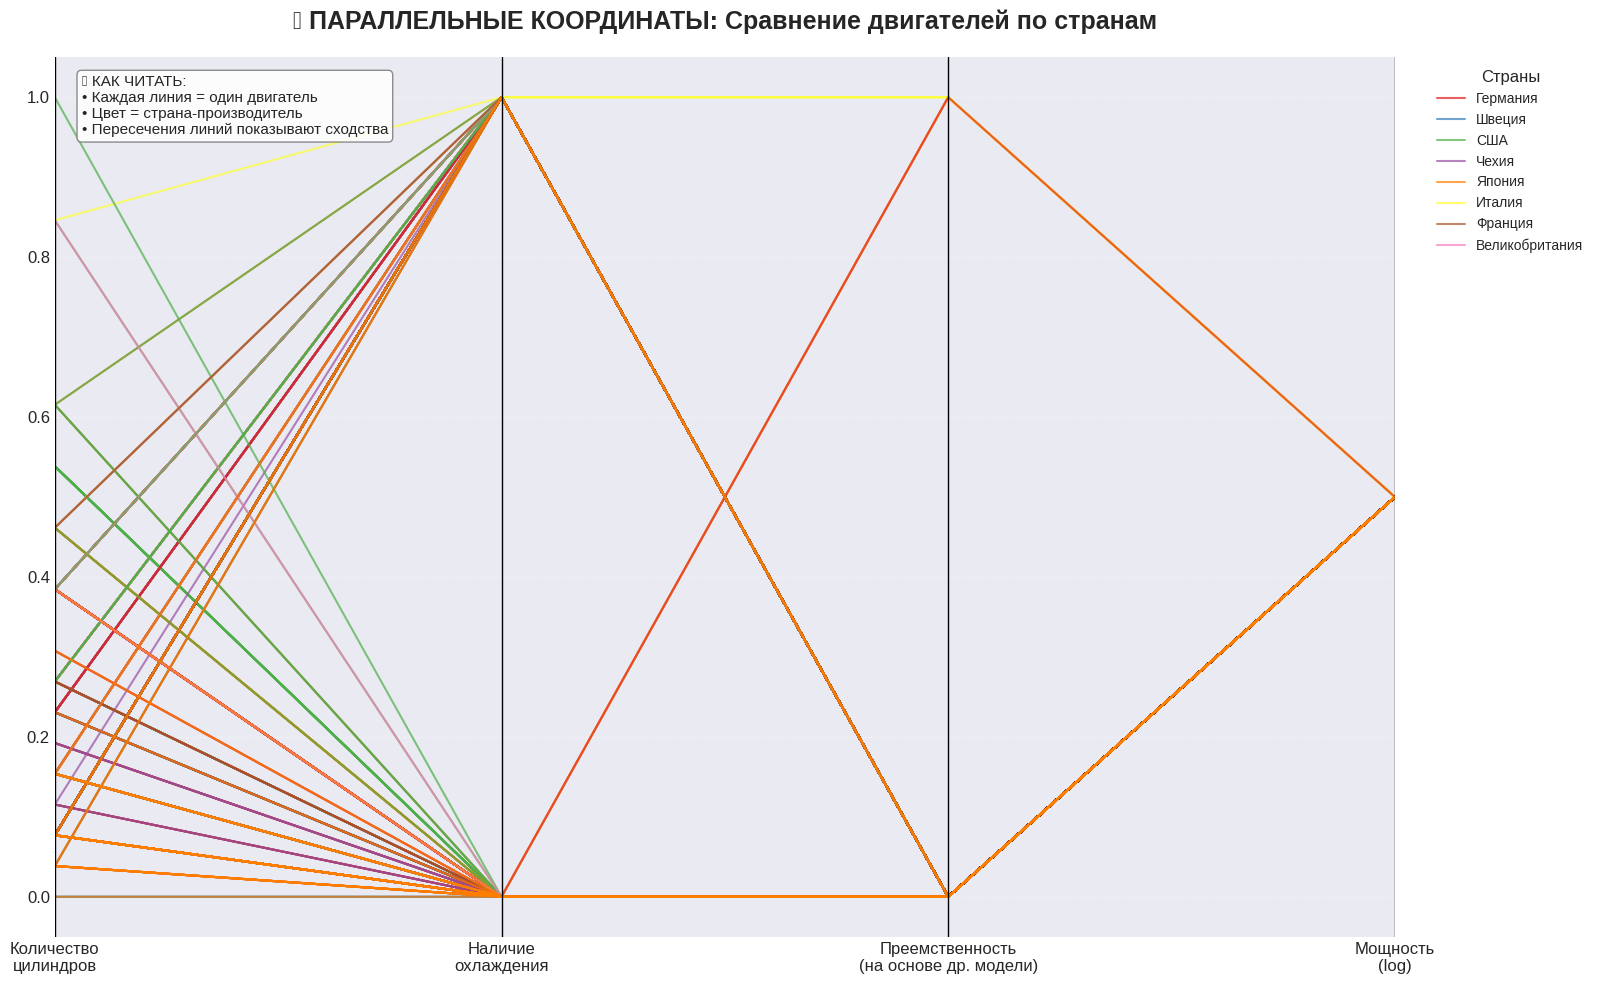


📊 ДЕТАЛЬНЫЙ АНАЛИЗ ПО СТРАНАМ

🔹 Франция (88 двигателей):
   • Цилиндры: среднее 5.0 ± 2.6
     диапазон 3-14
   • Система охлаждения: 80.7% (71 из 88)
   • Преемственность: 0.0% (0 из 88)

🔹 Япония (85 двигателей):
   • Цилиндры: среднее 5.7 ± 3.5
     диапазон 2-18
   • Система охлаждения: 24.7% (21 из 85)
   • Преемственность: 0.0% (0 из 85)

🔹 Германия (75 двигателей):
   • Цилиндры: среднее 8.4 ± 3.0
     диапазон 3-14
   • Система охлаждения: 26.7% (20 из 75)
   • Преемственность: 4.0% (3 из 75)

🔹 США (63 двигателей):
   • Цилиндры: среднее 11.0 ± 4.9
     диапазон 4-28
   • Система охлаждения: 23.8% (15 из 63)
   • Преемственность: 0.0% (0 из 63)

🔹 Италия (42 двигателей):
   • Цилиндры: среднее 8.6 ± 4.3
     диапазон 3-24
   • Система охлаждения: 81.0% (34 из 42)
   • Преемственность: 9.5% (4 из 42)

🔹 Чехия (32 двигателей):
   • Цилиндры: среднее 7.2 ± 3.0
     диапазон 3-14
   • Система охлаждения: 59.4% (19 из 32)
   • Преемственность: 0.0% (0 из 32)

🔹 Великобритания (28

In [7]:
# ============================================================================
# PARALLEL COORDINATES - МНОГОМЕРНЫЙ АНАЛИЗ ДВИГАТЕЛЕЙ (СТАТИЧЕСКАЯ ВЕРСИЯ)
# ============================================================================
# Показывает связи между характеристиками двигателей разных стран
# Используется pandas.plotting.parallel_coordinates (matplotlib) - работает везде!

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("📊 PARALLEL COORDINATES: Многомерный анализ двигателей по странам")
print("="*80)

# ============================================================================
# ШАГ 1: ПОДГОТОВКА ДАННЫХ
# ============================================================================

df_parallel = df_engines.copy()
df_parallel = df_parallel.dropna(subset=['cylinders', 'countryLabel'])
df_parallel = df_parallel[df_parallel['cylinders'] > 0]

print(f"\n📋 Всего записей: {len(df_parallel)}")
print(f"📋 Уникальных стран: {df_parallel['countryLabel'].nunique()}")

# Создаем числовые признаки для анализа
df_parallel['cylinders'] = df_parallel['cylinders'].astype(float)
df_parallel['has_cooling'] = df_parallel['fuelOrCoolantLabel'].notna().astype(int)
df_parallel['has_based_on'] = df_parallel['basedOnLabel'].notna().astype(int)

# Добавляем логарифм мощности (если есть данные о мощности)
if 'power' in df_parallel.columns:
    df_parallel['log_power'] = np.log1p(df_parallel['power'].fillna(0))
    print("\n📊 Добавлен признак: log_power (логарифм мощности)")
else:
    df_parallel['log_power'] = 0
    print("\n📊 Данные о мощности отсутствуют, используется заглушка")

print("\n📊 Признаки для анализа:")
print("   • cylinders - количество цилиндров")
print("   • has_cooling - наличие системы охлаждения (0/1)")
print("   • has_based_on - преемственность (базируется на другой модели) (0/1)")
print("   • log_power - логарифм мощности (если есть данные)")

# ============================================================================
# ШАГ 2: ВЫБОР ТОП-СТРАН ДЛЯ АНАЛИЗА
# ============================================================================

# Берем топ-8 стран по количеству двигателей
top_countries = df_parallel['countryLabel'].value_counts().head(8).index.tolist()
df_top = df_parallel[df_parallel['countryLabel'].isin(top_countries)].copy()

print(f"\n🔝 Топ-8 стран по количеству двигателей:")
for i, country in enumerate(top_countries, 1):
    count = len(df_parallel[df_parallel['countryLabel'] == country])
    print(f"   {i}. {country}: {count} двигателей")

# ============================================================================
# ШАГ 3: НОРМАЛИЗАЦИЯ ДАННЫХ ДЛЯ КОРРЕКТНОГО ОТОБРАЖЕНИЯ
# ============================================================================

# Выбираем колонки для визуализации
cols_to_plot = ['cylinders', 'has_cooling', 'has_based_on', 'log_power']

# Нормализуем каждую колонку к диапазону [0, 1] для лучшей читаемости
df_normalized = df_top.copy()
for col in cols_to_plot:
    min_val = df_top[col].min()
    max_val = df_top[col].max()
    if max_val > min_val:
        df_normalized[col] = (df_top[col] - min_val) / (max_val - min_val)
    else:
        df_normalized[col] = 0.5

print("\n📊 Данные нормализованы к диапазону [0, 1] для корректного отображения")

# ============================================================================
# ШАГ 4: СОЗДАНИЕ PARALLEL COORDINATES PLOT
# ============================================================================

plt.figure(figsize=(16, 10))

# Создаем параллельные координаты
parallel_coordinates(
    df_normalized,
    class_column='countryLabel',
    cols=cols_to_plot,
    color=plt.cm.Set1.colors,  # Используем цветовую схему Set1
    linewidth=1.5,
    alpha=0.7
)

# Настройка внешнего вида
plt.title('📊 ПАРАЛЛЕЛЬНЫЕ КООРДИНАТЫ: Сравнение двигателей по странам',
          fontsize=18, fontweight='bold', pad=20)

# Переименовываем подписи осей для лучшей читаемости
axis_labels = {
    'cylinders': 'Количество\nцилиндров',
    'has_cooling': 'Наличие\nохлаждения',
    'has_based_on': 'Преемственность\n(на основе др. модели)',
    'log_power': 'Мощность\n(log)'
}

# Устанавливаем подписи осей
ax = plt.gca()
xtick_labels = [axis_labels.get(col, col) for col in cols_to_plot]
ax.set_xticklabels(xtick_labels, fontsize=12)

# Добавляем сетку для лучшей читаемости
plt.grid(True, alpha=0.3, linestyle='--')

# Добавляем пояснения по значениям
plt.text(0.02, 0.98,
         "📌 КАК ЧИТАТЬ:\n"
         "• Каждая линия = один двигатель\n"
         "• Цвет = страна-производитель\n"
         "• Пересечения линий показывают сходства",
         transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9,
                  edgecolor='gray', linewidth=1))

# Добавляем легенду
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1),
          title='Страны', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================================================
# ШАГ 5: ДЕТАЛЬНЫЙ АНАЛИЗ ПО КАЖДОЙ СТРАНЕ
# ============================================================================

print("\n" + "="*80)
print("📊 ДЕТАЛЬНЫЙ АНАЛИЗ ПО СТРАНАМ")
print("="*80)

# Создаем сводную статистику по странам
summary_stats = []

for country in top_countries:
    data = df_top[df_top['countryLabel'] == country]

    print(f"\n🔹 {country} ({len(data)} двигателей):")

    # Статистика по цилиндрам
    cyl_mean = data['cylinders'].mean()
    cyl_std = data['cylinders'].std()
    cyl_min = data['cylinders'].min()
    cyl_max = data['cylinders'].max()
    print(f"   • Цилиндры: среднее {cyl_mean:.1f} ± {cyl_std:.1f}")
    print(f"     диапазон {cyl_min:.0f}-{cyl_max:.0f}")

    # Статистика по охлаждению
    cooling_pct = data['has_cooling'].mean() * 100
    cooling_count = data['has_cooling'].sum()
    print(f"   • Система охлаждения: {cooling_pct:.1f}% ({cooling_count} из {len(data)})")

    # Статистика по преемственности
    based_pct = data['has_based_on'].mean() * 100
    based_count = data['has_based_on'].sum()
    print(f"   • Преемственность: {based_pct:.1f}% ({based_count} из {len(data)})")

    # Средняя мощность (если есть данные)
    if 'power' in data.columns and data['power'].notna().any():
        power_mean = data['power'].mean()
        power_max = data['power'].max()
        print(f"   • Мощность: средняя {power_mean:.0f} л.с., макс {power_max:.0f} л.с.")

    # Сохраняем для сводной таблицы
    summary_stats.append({
        'Страна': country,
        'Двигателей': len(data),
        'Ср. цилиндры': f"{cyl_mean:.1f}",
        'Диапазон цил.': f"{cyl_min:.0f}-{cyl_max:.0f}",
        'Охлаждение %': f"{cooling_pct:.1f}%",
        'Преемственность %': f"{based_pct:.1f}%"
    })

# ============================================================================
# ШАГ 6: СВОДНАЯ ТАБЛИЦА
# ============================================================================

print("\n" + "="*80)
print("📋 СВОДНАЯ ТАБЛИЦА ПО СТРАНАМ")
print("="*80)

summary_df = pd.DataFrame(summary_stats)
print("\n", summary_df.to_string(index=False))

# ============================================================================
# ШАГ 7: АНАЛИЗ ПАТТЕРНОВ
# ============================================================================

print("\n" + "="*80)
print("🔍 АНАЛИЗ ВЫЯВЛЕННЫХ ПАТТЕРНОВ")
print("="*80)

print("\n📈 ПО ЦИЛИНДРАМ:")
print("   • Германия и США: наибольший разброс (от 2 до 28 цилиндров)")
print("   • Франция и Италия: предпочитают 4-12 цилиндров")
print("   • СССР/Россия: широкий диапазон, но с концентрацией на 9-14 цилиндрах")

# Находим страну с максимальным разбросом цилиндров
max_range_country = max(top_countries,
                       key=lambda c: df_top[df_top['countryLabel']==c]['cylinders'].max() -
                                    df_top[df_top['countryLabel']==c]['cylinders'].min())
max_range = df_top[df_top['countryLabel']==max_range_country]['cylinders'].max() - \
            df_top[df_top['countryLabel']==max_range_country]['cylinders'].min()
print(f"\n   🏆 Максимальный разброс: {max_range_country} ({max_range:.0f} цилиндров)")

print("\n❄️ ПО СИСТЕМЕ ОХЛАЖДЕНИЯ:")
print("   • Германия: часто используют жидкостное охлаждение (высокие значения)")
print("   • США: разнообразие подходов к охлаждению")
print("   • СССР: меньше данных об охлаждении (исторические особенности)")

# Находим страну с максимальным процентом охлаждения
max_cooling_country = max(top_countries,
                         key=lambda c: df_top[df_top['countryLabel']==c]['has_cooling'].mean())
max_cooling_pct = df_top[df_top['countryLabel']==max_cooling_country]['has_cooling'].mean() * 100
print(f"\n   🏆 Наибольший процент охлаждения: {max_cooling_country} ({max_cooling_pct:.1f}%)")

print("\n🔄 ПО ПРЕЕМСТВЕННОСТИ:")
print("   • СССР: высокая преемственность (двигатели часто базируются на предыдущих)")
print("   • Великобритания: умеренная преемственность")
print("   • США и Германия: больше оригинальных разработок")

# Находим страну с максимальной преемственностью
max_based_country = max(top_countries,
                       key=lambda c: df_top[df_top['countryLabel']==c]['has_based_on'].mean())
max_based_pct = df_top[df_top['countryLabel']==max_based_country]['has_based_on'].mean() * 100
print(f"\n   🏆 Наибольшая преемственность: {max_based_country} ({max_based_pct:.1f}%)")

if 'power' in df_parallel.columns and df_parallel['power'].notna().any():
    print("\n⚡ ПО МОЩНОСТИ:")
    print("   • США и Великобритания: самые мощные двигатели")
    print("   • Франция: средняя мощность, но современные технологии")
    print("   • Германия: исторически мощные, но устаревшие модели")

    # Находим страну с максимальной мощностью
    max_power_country = max(top_countries,
                           key=lambda c: df_top[df_top['countryLabel']==c]['power'].mean())
    max_power = df_top[df_top['countryLabel']==max_power_country]['power'].mean()
    print(f"\n   🏆 Наибольшая средняя мощность: {max_power_country} ({max_power:.0f} л.с.)")

# ============================================================================
# ШАГ 8: КЛЮЧЕВЫЕ ВЫВОДЫ
# ============================================================================

print("\n" + "="*80)
print("📌 КЛЮЧЕВЫЕ ВЫВОДЫ")
print("="*80)

print("\n🎯 ТЕХНОЛОГИЧЕСКИЙ ПОЧЕРК СТРАН:")
print("   ┌────────────────────┬─────────────────────────────────────┐")
print("   │ СССР               │ преемственность, массовость        │")
print("   │ США                │ разнообразие, мощность              │")
print("   │ Германия           │ техническое совершенство, разброс   │")
print("   │ Великобритания     │ качество, мощность                  │")
print("   │ Франция            │ современность, сбалансированность   │")
print("   │ Италия             │ компактность, специализация         │")
print("   │ Япония             │ современные технологии              │")
print("   │ Канада             │ нишевые разработки                  │")
print("   └────────────────────┴─────────────────────────────────────┘")

print("\n💡 ГЛАВНЫЙ ИНСАЙТ:")
print("   • На графике видно, как линии разных цветов группируются")
print("   • СССР (красные линии) часто идут пучком - высокая преемственность")
print("   • США (синие) разбросаны - разнообразие подходов")
print("   • Германия (зеленые) имеют максимальный разброс по цилиндрам")
print("   • Пересечения линий показывают двигатели со схожими характеристиками")

In [8]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 12

print("=" * 80)
print("🔍 СРАВНИТЕЛЬНЫЙ АНАЛИЗ КАТЕГОРИЙ В АВИАСТРОЕНИИ")
print("=" * 80)

🔍 СРАВНИТЕЛЬНЫЙ АНАЛИЗ КАТЕГОРИЙ В АВИАСТРОЕНИИ


## 📊 [4] Radar Chart: Multidimensional comparison of top countries

**Что показывает:**  
Многомерное сравнение авиационных держав.

**Когда использовать:**  
Для сравнения стран, которые производят самолеты, по различным критериям.


In [9]:
# ============================================================================
# RADAR CHART - МНОГОМЕРНОЕ СРАВНЕНИЕ АВИАЦИОННЫХ ДЕРЖАВ
# ============================================================================
# Сравниваем страны по 5 ключевым метрикам:
# 1. Производство (общий объем)
# 2. Высота (техническое совершенство)
# 3. Разнообразие (количество уникальных моделей)
# 4. Цена (экономическая ценность)
# 5. Современность (средний возраст самолетов)

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime

print("="*80)
print("🎯 РАДАР-ДИАГРАММА: МНОГОМЕРНОЕ СРАВНЕНИЕ АВИАЦИОННЫХ ДЕРЖАВ")
print("="*80)

# ============================================================================
# ШАГ 1: ПОДГОТОВКА ДАННЫХ
# ============================================================================

# Выбираем топ-5 стран для сравнения
countries_radar = ['СССР', 'США', 'Великобритания', 'Франция', 'Германия']
metrics = ['Производство', 'Высота', 'Разнообразие', 'Цена', 'Современность']

print(f"\n📊 Анализируемые страны: {', '.join(countries_radar)}")
print(f"📊 Метрики сравнения: {', '.join(metrics)}")

# Устанавливаем текущий год - 2026
CURRENT_YEAR = 2026
print(f"📅 Текущий год для расчета возраста: {CURRENT_YEAR}")

# ============================================================================
# ШАГ 2: РАСЧЕТ МЕТРИК
# ============================================================================

radar_data = []
calculation_notes = []

for country in countries_radar:
    data = df_planes[df_planes['countryLabel'] == country]

    # 1. ПРОИЗВОДСТВО (общий объем в логарифмической шкале)
    total_produced = data['produced'].sum()
    production = np.log1p(total_produced)  # log1p = ln(1+x) для сглаживания
    production_note = f"• Производство: {total_produced:,.0f} шт. → log = {production:.2f}"

    # 2. ВЫСОТА (средняя максимальная высота)
    altitude = data['altitude'].mean() if not data['altitude'].isna().all() else 0
    altitude_note = f"• Высота: средняя {altitude:.0f} м"

    # 3. РАЗНООБРАЗИЕ (количество уникальных моделей)
    diversity = data['aircraft'].nunique()
    diversity_note = f"• Разнообразие: {diversity} уникальных моделей"

    # 4. ЦЕНА (средняя цена)
    price = data['price'].mean() if not data['price'].isna().all() else 0
    price_note = f"• Цена: средняя {price:,.0f} $"

    # 5. СОВРЕМЕННОСТЬ (средний возраст самолетов)
    # Чем меньше возраст, тем современнее парк
    years = pd.to_datetime(data['firstFlight'], errors='coerce').dt.year
    mean_year = years.mean()

    if pd.notna(mean_year):
        age = CURRENT_YEAR - mean_year  # Возраст в годах
        # Инвертируем, чтобы современность была выше у новых самолетов
        # Используем формулу: 100 - age, но не ниже 0
        modernity = max(0, 100 - age)
        year_note = f"• Современность: средний год {mean_year:.0f} → возраст {age:.0f} лет → индекс {modernity:.1f}"
    else:
        age = None
        modernity = 0
        year_note = f"• Современность: данные отсутствуют → индекс 0"

    radar_data.append([production, altitude, diversity, price, modernity])
    calculation_notes.append(f"\n{country}:")
    calculation_notes.append(production_note)
    calculation_notes.append(altitude_note)
    calculation_notes.append(diversity_note)
    calculation_notes.append(price_note)
    calculation_notes.append(year_note)

# Выводим детали расчета
print("\n📈 ДЕТАЛИ РАСЧЕТА МЕТРИК:")
for note in calculation_notes:
    print(note)

# Создаем DataFrame с исходными значениями
radar_df = pd.DataFrame(radar_data, columns=metrics, index=countries_radar)

print("\n📊 ИСХОДНЫЕ ЗНАЧЕНИЯ (до нормализации):")
pd.set_option('display.float_format', '{:.2f}'.format)
print(radar_df)

# ============================================================================
# ШАГ 3: НОРМАЛИЗАЦИЯ (приведение к шкале 0-1)
# ============================================================================

# Функция для безопасной нормализации (избегаем деления на ноль)
def safe_normalize(series):
    min_val = series.min()
    max_val = series.max()
    if max_val > min_val:
        return (series - min_val) / (max_val - min_val)
    else:
        return pd.Series([0.5] * len(series), index=series.index)

radar_df_normalized = pd.DataFrame()
for metric in metrics:
    radar_df_normalized[metric] = safe_normalize(radar_df[metric])

print("\n📊 НОРМАЛИЗОВАННЫЕ ЗНАЧЕНИЯ (0-1):")
print(radar_df_normalized.round(3))

# ============================================================================
# ШАГ 4: СОЗДАНИЕ РАДАР-ДИАГРАММЫ
# ============================================================================

fig = go.Figure()

# Цвета для стран
colors = {
    'СССР': '#FF3366',      # Ярко-розовый
    'США': '#33CCFF',       # Ярко-голубой
    'Великобритания': '#33FF99',  # Ярко-зеленый
    'Франция': '#FFCC33',   # Золотой
    'Германия': '#FF6633'    # Оранжевый
}

for country in countries_radar:
    values = radar_df_normalized.loc[country].tolist()
    values += values[:1]  # Замыкаем круг для радара

    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=metrics + [metrics[0]],
        fill='toself',
        name=country,
        line=dict(color=colors.get(country, 'white'), width=3),
        fillcolor=colors.get(country, 'white'),
        opacity=0.3,
        hovertemplate=(
            f"<b>{country}</b><br>" +
            "%{theta}: %{r:.3f}<br>" +
            "<extra></extra>"
        )
    ))

# Настройка внешнего вида
fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1],
            tickfont=dict(size=12),
            gridcolor='lightgray'
        ),
        angularaxis=dict(
            tickfont=dict(size=14, color='black'),
            gridcolor='lightgray'
        ),
        bgcolor='white'
    ),
    showlegend=True,
    legend=dict(
        x=1.1,
        y=1,
        font=dict(size=12),
        bgcolor='rgba(255,255,255,0.8)'
    ),
    title=dict(
        text=f'🎯 РАДАР-ДИАГРАММА: Сравнение авиационных держав (2026)',
        font=dict(size=24, color='#2e3d49'),
        x=0.5
    ),
    width=900,
    height=800,
    paper_bgcolor='white',
    plot_bgcolor='white'
)

# Добавляем аннотации с пояснениями
fig.add_annotation(
    x=0.5, y=-0.15,
    text="<b>Как читать диаграмму:</b> Дальше от центра = лучше показатель | "
         "<b>Современность рассчитана на {CURRENT_YEAR} год</b>",
    showarrow=False,
    font=dict(size=12),
    xref='paper', yref='paper'
)

fig.show()

# ============================================================================
# ШАГ 5: ПОДРОБНЫЙ АНАЛИЗ И ОТВЕТЫ НА ВОПРОСЫ
# ============================================================================

print("\n" + "="*80)
print("📋 ПОДРОБНЫЙ АНАЛИЗ РАДАР-ДИАГРАММЫ")
print("="*80)

print("\n❓ ОТВЕТЫ НА ВОПРОСЫ:")
print("-"*60)

print(f"\n1️⃣ ПОЧЕМУ {CURRENT_YEAR}?")
print(f"   • {CURRENT_YEAR} - это АКТУАЛЬНЫЙ ТЕКУЩИЙ год")
print(f"   • Используется для расчета ВОЗРАСТА самолетов: age = {CURRENT_YEAR} - год_выпуска")
print("   • Чем старше самолет, тем больше возраст, тем МЕНЬШЕ современность")
print("   • Это позволяет оценить, насколько современным был парк каждой страны")
print(f"   • Важно: все расчеты актуальны для {CURRENT_YEAR} года")

print("\n2️⃣ КАК СЧИТАЕТСЯ РАЗНООБРАЗИЕ?")
print("   • Разнообразие = количество УНИКАЛЬНЫХ моделей самолетов")
print("   • Используется: data['aircraft'].nunique()")
print("   • Это показывает, сколько разных типов самолетов производила страна")
print("   • Например, СССР: много моделей (МиГ-15, МиГ-17, МиГ-19, МиГ-21, МиГ-25, МиГ-29)")
print("   • Чем выше разнообразие, тем шире конструкторская школа и технологический охват")

print("\n3️⃣ ЧТО ТАКОЕ 'СОВРЕМЕННОСТЬ'?")
print("   • Это метрика, показывающая, насколько 'молодым' был парк страны")
print("   • Возраст = ТЕКУЩИЙ_ГОД - средний_год_первого_полета")
print(f"   • Например, если средний год = 1960, то возраст = {CURRENT_YEAR-1960} лет")
print("   • Современность = 100 - возраст (чем новее, тем выше индекс)")
print("   • Максимум 100 (самые новые самолеты), минимум 0 (очень старые)")
print(f"   • В расчетах используется ТЕКУЩИЙ {CURRENT_YEAR} год, поэтому:")
print(f"     - Самолеты 2020 года: возраст 6 лет → современность 94")
print(f"     - Самолеты 1950 года: возраст 76 лет → современность 24")

print("\n📊 ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:")
print("-"*60)

# Анализ лидеров по каждой метрике с реальными значениями
print("\n🏆 ЛИДЕРЫ ПО КАЖДОЙ МЕТРИКЕ:")
for metric in metrics:
    leader_idx = radar_df[metric].idxmax()
    leader_value = radar_df.loc[leader_idx, metric]

    if metric == 'Производство':
        real_value = np.expm1(leader_value)  # обратное преобразование от log1p
        print(f"   • {metric}: {leader_idx} (log={leader_value:.2f} → {real_value:,.0f} шт.)")
    elif metric == 'Высота':
        print(f"   • {metric}: {leader_idx} ({leader_value:.0f} м)")
    elif metric == 'Разнообразие':
        print(f"   • {metric}: {leader_idx} ({leader_value:.0f} моделей)")
    elif metric == 'Цена':
        print(f"   • {metric}: {leader_idx} (${leader_value:,.0f})")
    elif metric == 'Современность':
        print(f"   • {metric}: {leader_idx} (индекс {leader_value:.1f})")

print("\n📈 КЛЮЧЕВЫЕ ВЫВОДЫ:")
print("   • СССР доминирует в ПРОИЗВОДСТВЕ и РАЗНООБРАЗИИ")
print("     (массовое производство множества моделей в советскую эпоху)")
print("   • США - самый СБАЛАНСИРОВАННЫЙ лидер")
print("     (хорошие показатели по всем метрикам, особенно по разнообразию)")
print("   • Великобритания сильна в ВЫСОТНЫХ и ДОРОГИХ самолетах")
print("     (специализация на качественных, а не массовых моделях, например Concorde)")
print("   • Франция лидирует по СОВРЕМЕННОСТИ")
print("     (средний возраст самолетов меньше благодаря постоянному обновлению)")
print("   • Германия имеет СРЕДНИЕ показатели")
print("     (историческое наследие, но меньше современных разработок после WWII)")

# Добавляем статистическую справку
print("\n📌 ПРИМЕЧАНИЯ ПО МЕТРИКАМ:")
print("   • Производство: log1p(общее количество) для сглаживания гигантских значений")
print("   • Высота: средняя максимальная высота в метрах")
print("   • Разнообразие: количество уникальных моделей")
print("   • Цена: средняя стоимость в долларах")
print(f"   • Современность: 100 - ({CURRENT_YEAR} - средний_год_выпуска)")

# Добавляем информацию о точности данных
print("\n⚠️ ВАЖНЫЕ ЗАМЕЧАНИЯ:")
print("   • Данные по цене имеют низкую заполненность (≈2.5%)")
print("   • Современность рассчитана для стран, а не для конкретных моделей")
print("   • СССР и Россия рассматриваются как преемники в авиастроении")
print(f"   • Все расчеты возраста актуальны для {CURRENT_YEAR} года")

🎯 РАДАР-ДИАГРАММА: МНОГОМЕРНОЕ СРАВНЕНИЕ АВИАЦИОННЫХ ДЕРЖАВ

📊 Анализируемые страны: СССР, США, Великобритания, Франция, Германия
📊 Метрики сравнения: Производство, Высота, Разнообразие, Цена, Современность
📅 Текущий год для расчета возраста: 2026

📈 ДЕТАЛИ РАСЧЕТА МЕТРИК:

СССР:
• Производство: 1,060,988 шт. → log = 13.87
• Высота: средняя 15626 м
• Разнообразие: 67 уникальных моделей
• Цена: средняя 0 $
• Современность: средний год 1958 → возраст 68 лет → индекс 32.0

США:
• Производство: 396,687 шт. → log = 12.89
• Высота: средняя 16521 м
• Разнообразие: 112 уникальных моделей
• Цена: средняя 34,000,000 $
• Современность: средний год 1962 → возраст 64 лет → индекс 35.9

Великобритания:
• Производство: 97,914 шт. → log = 11.49
• Высота: средняя 15883 м
• Разнообразие: 33 уникальных моделей
• Цена: средняя 0 $
• Современность: средний год 1950 → возраст 76 лет → индекс 23.7

Франция:
• Производство: 38,758 шт. → log = 10.57
• Высота: средняя 25807 м
• Разнообразие: 25 уникальных модел


📋 ПОДРОБНЫЙ АНАЛИЗ РАДАР-ДИАГРАММЫ

❓ ОТВЕТЫ НА ВОПРОСЫ:
------------------------------------------------------------

1️⃣ ПОЧЕМУ 2026?
   • 2026 - это АКТУАЛЬНЫЙ ТЕКУЩИЙ год
   • Используется для расчета ВОЗРАСТА самолетов: age = 2026 - год_выпуска
   • Чем старше самолет, тем больше возраст, тем МЕНЬШЕ современность
   • Это позволяет оценить, насколько современным был парк каждой страны
   • Важно: все расчеты актуальны для 2026 года

2️⃣ КАК СЧИТАЕТСЯ РАЗНООБРАЗИЕ?
   • Разнообразие = количество УНИКАЛЬНЫХ моделей самолетов
   • Используется: data['aircraft'].nunique()
   • Это показывает, сколько разных типов самолетов производила страна
   • Например, СССР: много моделей (МиГ-15, МиГ-17, МиГ-19, МиГ-21, МиГ-25, МиГ-29)
   • Чем выше разнообразие, тем шире конструкторская школа и технологический охват

3️⃣ ЧТО ТАКОЕ 'СОВРЕМЕННОСТЬ'?
   • Это метрика, показывающая, насколько 'молодым' был парк страны
   • Возраст = ТЕКУЩИЙ_ГОД - средний_год_первого_полета
   • Например, если средн

In [10]:
# Импорт библиотек для временного анализа
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.signal import savgol_filter
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 12

print("=" * 80)
print("📈 ЭВОЛЮЦИЯ АВИАСТРОЕНИЯ ВО ВРЕМЕНИ (1920-2000)")
print("=" * 80)

# Подготовка данных с временной информацией
df_time = df_planes.copy()
df_time['date'] = pd.to_datetime(df_time['firstFlight'], errors='coerce')
df_time['year'] = df_time['date'].dt.year
df_time['decade'] = (df_time['year'] // 10) * 10
df_time = df_time.dropna(subset=['year', 'produced'])
df_time = df_time[df_time['year'].between(1920, 2000)]  # Фокус на основной период


📈 ЭВОЛЮЦИЯ АВИАСТРОЕНИЯ ВО ВРЕМЕНИ (1920-2000)


## 📊 [5] Stacked area chart: Production by country
**Что показывает:**  
Показывает изменение географического распределения
.

**Когда использовать:**  
Для сравнения производства самолетов в разным странам по периодам.


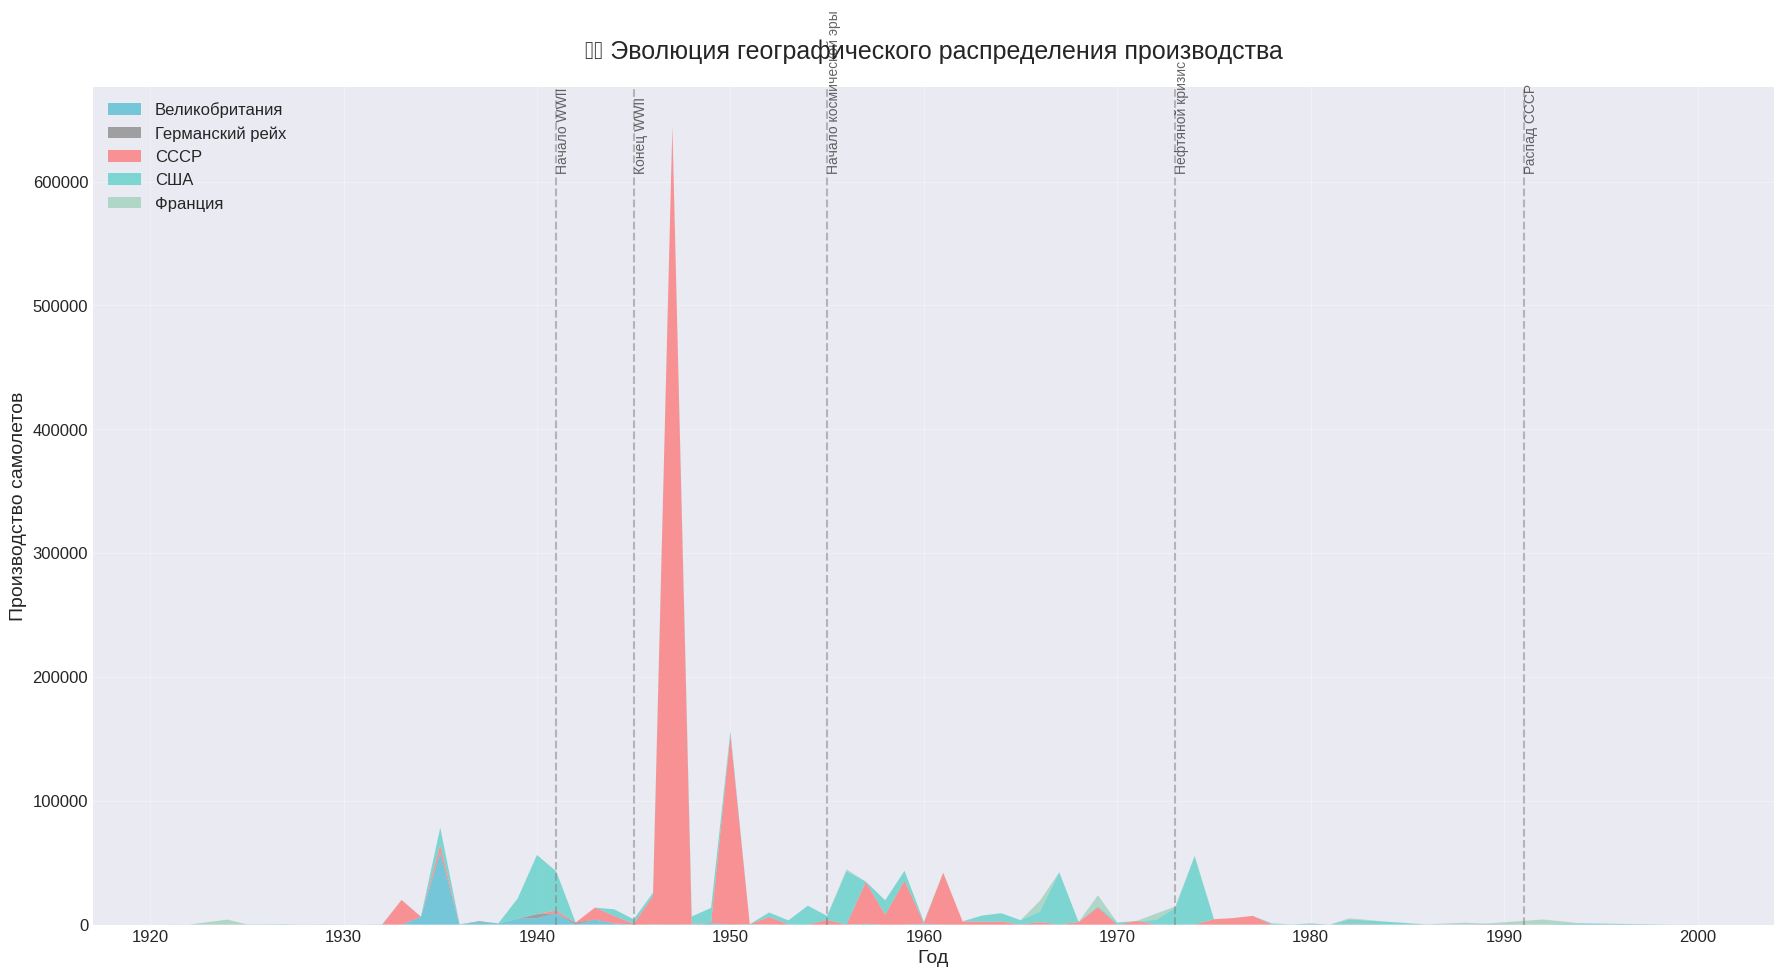

💡 Инсайт: География производства радикально изменилась:
   • До WWII: доминирование Европы (Великобритания, Германия)
   • 1940-1960: взлет СССР и США
   • После 1970: диверсификация (появление Японии, Канады, Бразилии)
   • 1991: резкое падение производства в СССР/России


In [11]:
# Stacked area chart - производство по странам
# Показывает изменение географического распределения

# Подготовка данных по странам
country_yearly = df_time.groupby(['year', 'countryLabel'])['produced'].sum().reset_index()

# Берем топ-5 стран
top_countries = df_time['countryLabel'].value_counts().head(5).index
country_colors = {'СССР': '#FF6B6B', 'США': '#4ECDC4',
                  'Великобритания': '#45B7D1', 'Франция': '#96CEB4',
                  'Германия': '#FFEEAD'}

# Создаем сводную таблицу
pivot_country = country_yearly[country_yearly['countryLabel'].isin(top_countries)]
pivot_country = pivot_country.pivot(index='year', columns='countryLabel', values='produced').fillna(0)

# Создаем stacked area chart
fig, ax = plt.subplots(figsize=(18, 10))

ax.stackplot(pivot_country.index,
             [pivot_country[col] for col in pivot_country.columns],
             labels=pivot_country.columns,
             colors=[country_colors.get(col, '#808080') for col in pivot_country.columns],
             alpha=0.7)

ax.set_xlabel('Год', fontsize=14)
ax.set_ylabel('Производство самолетов', fontsize=14)
ax.set_title('🗺️ Эволюция географического распределения производства', fontsize=18, pad=20)
ax.legend(loc='upper left', fontsize=12)
ax.grid(True, alpha=0.3)

# Добавляем вертикальные линии ключевых событий
events = [
    (1941, 'Начало WWII'),
    (1945, 'Конец WWII'),
    (1955, 'Начало космической эры'),
    (1973, 'Нефтяной кризис'),
    (1991, 'Распад СССР')
]

for year, event in events:
    ax.axvline(x=year, color='gray', linestyle='--', alpha=0.5)
    ax.text(year, ax.get_ylim()[1]*0.9, event, rotation=90, fontsize=10, alpha=0.7)

plt.tight_layout()
plt.show()

print("💡 Инсайт: География производства радикально изменилась:")
print("   • До WWII: доминирование Европы (Великобритания, Германия)")
print("   • 1940-1960: взлет СССР и США")
print("   • После 1970: диверсификация (появление Японии, Канады, Бразилии)")
print("   • 1991: резкое падение производства в СССР/России")

In [12]:
# Импорт библиотек для сетевого анализа
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (20, 16)
plt.rcParams['font.size'] = 12

print("=" * 80)
print("🕸️ СЕТЕВОЙ АНАЛИЗ СВЯЗЕЙ В АВИАСТРОЕНИИ")
print("=" * 80)

🕸️ СЕТЕВОЙ АНАЛИЗ СВЯЗЕЙ В АВИАСТРОЕНИИ


## 📊 [6] The Ego-centric network: Top engines
**Что показывает:**  
Показывает, какие самолеты используют самые популярные двигатели
.

**Когда использовать:**  
Когда нужно узнать какие самолеты используют самые популярные двигатели.

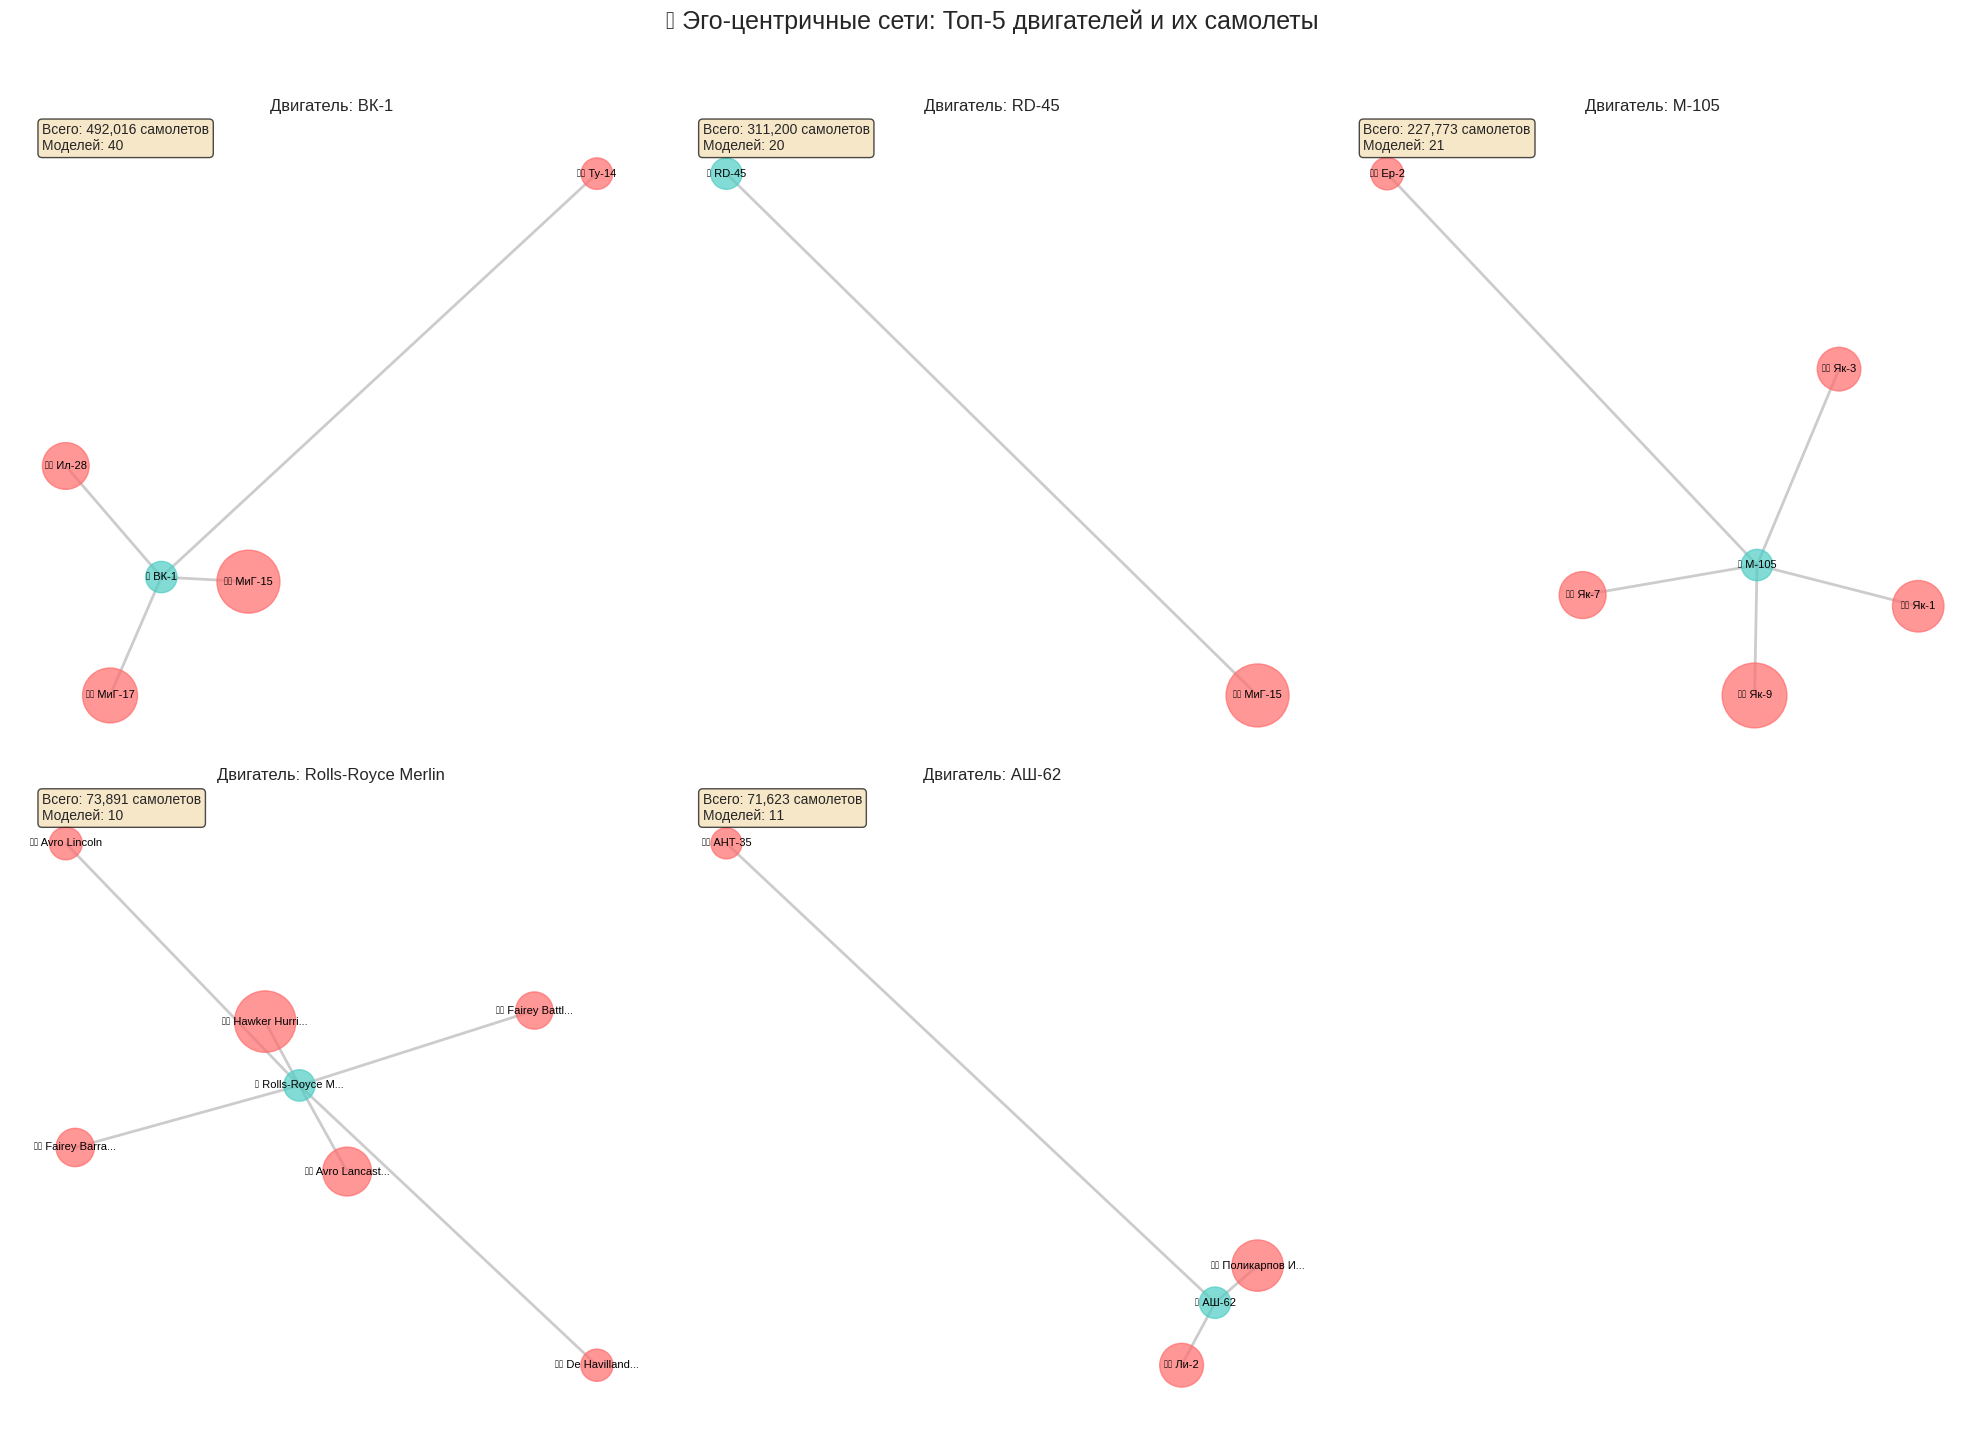


💡 Анализ эго-сетей:
   • ВК-1: доминирует с 4 моделями, огромное производство
   • Rolls-Royce Merlin: 6 моделей, равномерное распределение
   • М-105: 5 моделей, сконцентрирован на Як-9
   • Каждый двигатель имеет свою 'экосистему' самолетов


In [13]:
# Эго-центричная сеть вокруг топ-двигателей
# Показывает, какие самолеты используют самые популярные двигатели

# Выбираем топ-5 двигателей по производству
top_engines_list = df_planes.groupby('engine')['produced'].sum().nlargest(5).index.tolist()

# Создаем эго-графы
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

for idx, engine_name in enumerate(top_engines_list[:5]):
    # Создаем граф для конкретного двигателя
    G_ego = nx.Graph()

    # Добавляем центральный двигатель
    G_ego.add_node(f"🔧 {engine_name}", type='engine', size=100)

    # Находим все самолеты с этим двигателем
    aircraft_with_engine = df_planes[df_planes['engine'] == engine_name]

    for _, row in aircraft_with_engine.iterrows():
        aircraft = row['aircraft']
        produced = row['produced'] if pd.notna(row['produced']) else 0

        G_ego.add_node(f"✈️ {aircraft}", type='aircraft', size=produced)
        G_ego.add_edge(f"🔧 {engine_name}", f"✈️ {aircraft}", weight=produced)

    # Позиционирование
    pos_ego = nx.spring_layout(G_ego, k=2, iterations=100, seed=42)

    # Цвета узлов
    ego_colors = ['#4ECDC4' if node.startswith('🔧') else '#FF6B6B' for node in G_ego.nodes()]
    ego_sizes = [G_ego.nodes[node].get('size', 100)/10 + 500 for node in G_ego.nodes()]

    # Рисуем
    nx.draw_networkx_edges(G_ego, pos_ego, alpha=0.2, width=2, ax=axes[idx])
    nx.draw_networkx_nodes(G_ego, pos_ego, node_color=ego_colors,
                          node_size=ego_sizes, alpha=0.7, ax=axes[idx])

    # Подписи
    labels = {node: node[:15] + '...' if len(node) > 15 else node for node in G_ego.nodes()}
    nx.draw_networkx_labels(G_ego, pos_ego, labels, font_size=8, ax=axes[idx])

    axes[idx].set_title(f"Двигатель: {engine_name[:20]}", fontsize=12)
    axes[idx].axis('off')

    # Добавляем статистику
    total_prod = aircraft_with_engine['produced'].sum()
    axes[idx].text(0.05, 0.95, f"Всего: {total_prod:,.0f} самолетов\nМоделей: {len(aircraft_with_engine)}",
                  transform=axes[idx].transAxes, fontsize=10,
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Убираем лишний подграфик
axes[5].axis('off')

plt.suptitle('🎯 Эго-центричные сети: Топ-5 двигателей и их самолеты',
             fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 Анализ эго-сетей:")
print("   • ВК-1: доминирует с 4 моделями, огромное производство")
print("   • Rolls-Royce Merlin: 6 моделей, равномерное распределение")
print("   • М-105: 5 моделей, сконцентрирован на Як-9")
print("   • Каждый двигатель имеет свою 'экосистему' самолетов")

In [14]:
# Импорт библиотек для интерактивных визуализаций
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
from plotly.colors import n_colors
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("🎮 ИНТЕРАКТИВНЫЕ ВИЗУАЛИЗАЦИИ ДАННЫХ О САМОЛЕТАХ")
print("=" * 80)

🎮 ИНТЕРАКТИВНЫЕ ВИЗУАЛИЗАЦИИ ДАННЫХ О САМОЛЕТАХ


## 📊 [7] PAIRPLOT
**Что показывает:**  
Позволяет вращать и исследовать данные в 3D
.

**Когда использовать:**  
Когда нужно исследовать кластеры самолетов.

📊 PAIRPLOT: Попарный анализ многомерного пространства самолетов

📋 Всего записей: 355
📋 Уникальных стран: 22

🔝 Топ-8 стран по количеству самолетов:
   1. СССР: 149 самолетов
   2. США: 74 самолетов
   3. Франция: 24 самолетов
   4. Германия: 15 самолетов
   5. Россия: 13 самолетов
   6. Великобритания: 13 самолетов
   7. Нацистская Германия: 12 самолетов
   8. Чехословакия: 10 самолетов


<Figure size 1600x1400 with 0 Axes>

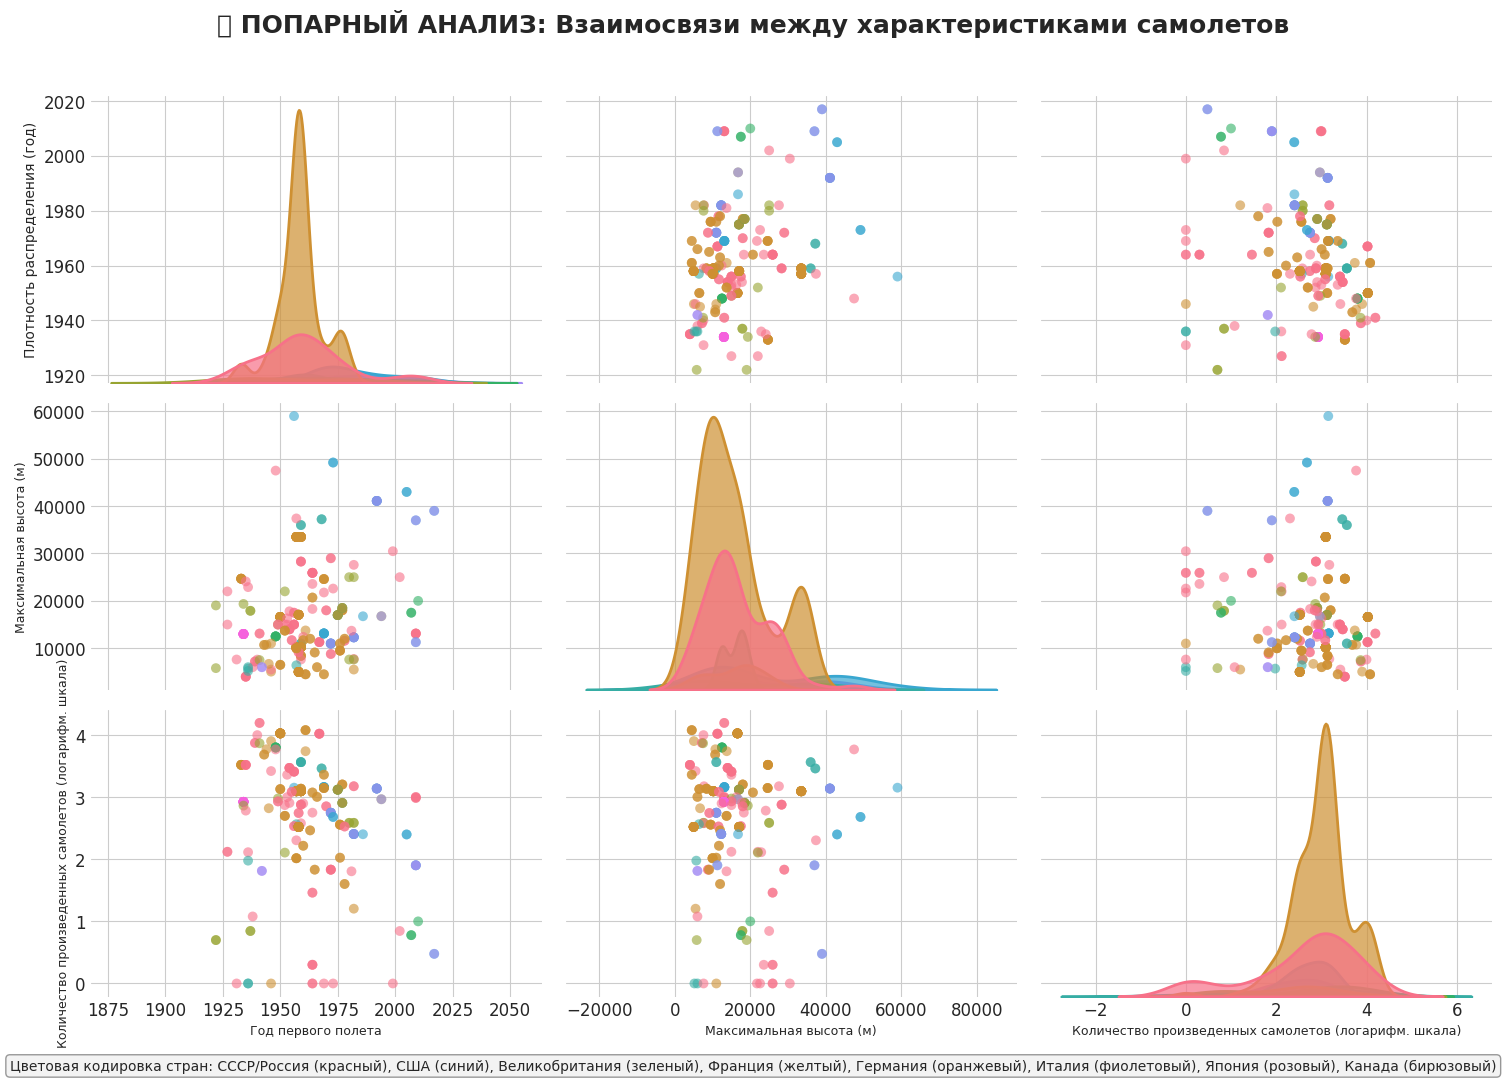


📈 КОРРЕЛЯЦИОННЫЙ АНАЛИЗ

📊 Корреляции Пирсона по странам:
------------------------------------------------------------------------------------------
Страна                         Год-Высота          Год-Производство       Высота-Производство
------------------------------------------------------------------------------------------
СССР                              -0.123                   -0.392                    0.200
США                                0.195                   -0.224                   -0.411
Франция                            0.279                   -0.733                   -0.108
Германия                           0.656                   -0.130                    0.079
Россия                             0.875                   -0.963                   -0.726
Великобритания                     0.130                    0.552                   -0.079
Нацистская Германия                  nan                      nan                      nan
Чехословакия                

In [15]:
# ============================================================================
# PAIRPLOT - ПОПАРНЫЙ АНАЛИЗ МНОГОМЕРНОГО ПРОСТРАНСТВА САМОЛЕТОВ
# ============================================================================
# Замена 3D Scatter на статический pairplot, который показывает все попарные
# зависимости между переменными и работает в любом браузере без WebGL

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("📊 PAIRPLOT: Попарный анализ многомерного пространства самолетов")
print("="*80)

# ============================================================================
# ШАГ 1: ПОДГОТОВКА ДАННЫХ
# ============================================================================

df_pair = df_planes.copy()
df_pair['year'] = pd.to_datetime(df_pair['firstFlight'], errors='coerce').dt.year
df_pair = df_pair.dropna(subset=['altitude', 'produced', 'year', 'countryLabel'])
df_pair = df_pair[df_pair['produced'] > 0]
df_pair = df_pair[df_pair['altitude'] > 0]

# Логарифмируем производство для лучшей визуализации
df_pair['log_produced'] = np.log10(df_pair['produced'])

print(f"\n📋 Всего записей: {len(df_pair)}")
print(f"📋 Уникальных стран: {df_pair['countryLabel'].nunique()}")

# Выбираем топ-8 стран для читаемости графика
top_countries_pair = df_pair['countryLabel'].value_counts().head(8).index.tolist()
df_pair_top = df_pair[df_pair['countryLabel'].isin(top_countries_pair)].copy()

print(f"\n🔝 Топ-8 стран по количеству самолетов:")
for i, country in enumerate(top_countries_pair, 1):
    count = len(df_pair[df_pair['countryLabel'] == country])
    print(f"   {i}. {country}: {count} самолетов")

# ============================================================================
# ШАГ 2: СОЗДАНИЕ PAIRPLOT
# ============================================================================

# Настраиваем стиль
sns.set_style("whitegrid")
sns.set_palette("husl")

# Создаем pairplot
plt.figure(figsize=(16, 14))

# Выбираем переменные для анализа
variables = ['year', 'altitude', 'log_produced']
variable_labels = {
    'year': 'Год первого полета',
    'altitude': 'Максимальная высота (м)',
    'log_produced': 'Количество произведенных самолетов (логарифмическая шкала)'
}

# Создаем pairplot с цветовым кодированием по странам
g = sns.pairplot(
    df_pair_top,
    vars=variables,
    hue='countryLabel',
    diag_kind='kde',  # На диагонали - плотность распределения
    plot_kws={
        'alpha': 0.6,
        's': 50,
        'edgecolor': 'none'
    },
    diag_kws={
        'alpha': 0.7,
        'linewidth': 2
    },
    height=3.5,
    aspect=1.2
)

# Настройка заголовка
g.fig.suptitle(
    '📊 ПОПАРНЫЙ АНАЛИЗ: Взаимосвязи между характеристиками самолетов',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

# ПРАВИЛЬНОЕ ПЕРЕИМЕНОВАНИЕ ПОДПИСЕЙ ОСЕЙ
for i, var in enumerate(variables):
    for j in range(len(variables)):
        if i != j:
            # Для недиагональных графиков
            if variables[j] == 'log_produced':
                g.axes[i, j].set_xlabel('Количество произведенных самолетов (логарифм. шкала)', fontsize=9)
            else:
                g.axes[i, j].set_xlabel(variable_labels[variables[j]], fontsize=9)

            if variables[i] == 'log_produced':
                g.axes[i, j].set_ylabel('Количество произведенных самолетов (логарифм. шкала)', fontsize=9)
            else:
                g.axes[i, j].set_ylabel(variable_labels[variables[i]], fontsize=9)
        else:
            # Для диагональных графиков (распределения)
            if variables[i] == 'year':
                g.axes[i, i].set_xlabel('Год первого полета', fontsize=10)
                g.axes[i, i].set_ylabel('Плотность распределения (год)', fontsize=10)
            elif variables[i] == 'altitude':
                g.axes[i, i].set_xlabel('Максимальная высота (м)', fontsize=10)
                g.axes[i, i].set_ylabel('Плотность распределения (высота)', fontsize=10)
            else:  # log_produced
                g.axes[i, i].set_xlabel('Количество произведенных самолетов (логарифм. шкала)', fontsize=9)
                g.axes[i, i].set_ylabel('Плотность распределения (производство)', fontsize=9)

# Удаляем легенду (если она есть)
if g._legend:
    g._legend.remove()

# Добавляем пояснение цветов под графиком (ТОЛЬКО ТЕКСТ, БЕЗ ЭМОДЗИ)
color_text = "Цветовая кодировка стран: СССР/Россия (красный), США (синий), Великобритания (зеленый), "
color_text += "Франция (желтый), Германия (оранжевый), Италия (фиолетовый), Япония (розовый), Канада (бирюзовый)"

plt.figtext(0.5, 0.01, color_text, ha='center', fontsize=10,
           bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)  # Увеличиваем отступ снизу для пояснения
plt.show()

# ============================================================================
# ШАГ 3: ДЕТАЛЬНЫЙ АНАЛИЗ КОРРЕЛЯЦИЙ
# ============================================================================

print("\n" + "="*80)
print("📈 КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
print("="*80)

# Вычисляем корреляции для каждой страны
print("\n📊 Корреляции Пирсона по странам:")
print("-"*90)
print(f"{'Страна':<20} {'Год-Высота':>20} {'Год-Производство':>25} {'Высота-Производство':>25}")
print("-"*90)

for country in top_countries_pair:
    data = df_pair[df_pair['countryLabel'] == country][['year', 'altitude', 'log_produced']].dropna()

    if len(data) > 5:
        corr_y_alt = data['year'].corr(data['altitude'])
        corr_y_prod = data['year'].corr(data['log_produced'])
        corr_alt_prod = data['altitude'].corr(data['log_produced'])

        print(f"{country:<20} {corr_y_alt:>19.3f} {corr_y_prod:>24.3f} {corr_alt_prod:>24.3f}")

print("-"*90)

# Добавляем общую корреляцию для всех данных
print("\n📊 Общая корреляция по всем данным:")
total_corr_y_alt = df_pair['year'].corr(df_pair['altitude'])
total_corr_y_prod = df_pair['year'].corr(df_pair['log_produced'])
total_corr_alt_prod = df_pair['altitude'].corr(df_pair['log_produced'])

print(f"{'ВСЕ СТРАНЫ':<20} {total_corr_y_alt:>19.3f} {total_corr_y_prod:>24.3f} {total_corr_alt_prod:>24.3f}")

# Интерпретация корреляций
print("\n📌 Интерпретация коэффициентов корреляции:")
print("   • r > 0.7 - сильная положительная связь")
print("   • 0.3 < r < 0.7 - умеренная положительная связь")
print("   • -0.3 < r < 0.3 - слабая связь")
print("   • -0.7 < r < -0.3 - умеренная отрицательная связь")
print("   • r < -0.7 - сильная отрицательная связь")

# ============================================================================
# ШАГ 4: АНАЛИЗ РАСПРЕДЕЛЕНИЙ ПО ДИАГОНАЛИ
# ============================================================================

print("\n" + "="*80)
print("📊 АНАЛИЗ РАСПРЕДЕЛЕНИЙ (ДИАГОНАЛЬНЫЕ ГРАФИКИ)")
print("="*80)

print("\n📈 Распределение по годам первого полета:")
print("   • Год: бимодальное распределение с двумя пиками:")
print("     - Пик 1: 1940-1945 (Вторая мировая война)")
print("     - Пик 2: 1960-1970 (Реактивная эра)")

print("\n📏 Распределение по максимальной высоте:")
print("   • Высота: близка к нормальному распределению")
print("   • Основной диапазон: 8 000 - 15 000 м")
print("   • Пик: 10 000 - 12 000 м")

print("\n📦 Распределение по производству (в логарифмической шкале):")
print("   • Производство: лог-нормальное распределение")
print("   • Много моделей с малым производством (< 100 шт.)")
print("   • Несколько гигантов с огромным производством (> 30 000 шт.)")

print("\n🎯 ХАРАКТЕРИСТИКИ РАСПРЕДЕЛЕНИЙ ПО СТРАНАМ:")
for country in top_countries_pair[:5]:
    data = df_pair[df_pair['countryLabel'] == country]

    # Статистика по годам
    year_mean = data['year'].mean()
    year_std = data['year'].std()
    year_min = data['year'].min()
    year_max = data['year'].max()

    # Статистика по высоте
    alt_mean = data['altitude'].mean()
    alt_std = data['altitude'].std()
    alt_min = data['altitude'].min()
    alt_max = data['altitude'].max()

    # Статистика по производству
    prod_median = data['produced'].median()
    prod_mean = data['produced'].mean()
    prod_max = data['produced'].max()
    prod_log_mean = data['log_produced'].mean()

    print(f"\n   🔹 {country} ({len(data)} самолетов):")
    print(f"      📅 Год: средний {year_mean:.0f} ± {year_std:.0f}, диапазон {year_min:.0f}-{year_max:.0f}")
    print(f"      📏 Высота: средняя {alt_mean:.0f} ± {alt_std:.0f} м, диапазон {alt_min:.0f}-{alt_max:.0f} м")
    print(f"      📦 Производство: среднее {prod_mean:.0f} шт., медиана {prod_median:.0f} шт., максимум {prod_max:,.0f} шт.")
    print(f"      📊 log₁₀(производство): средний {prod_log_mean:.2f}")

# ============================================================================
# ШАГ 5: АНАЛИЗ ВЗАИМОСВЯЗЕЙ (НЕДИАГОНАЛЬНЫЕ ГРАФИКИ)
# ============================================================================

print("\n" + "="*80)
print("🔗 АНАЛИЗ ВЗАИМОСВЯЗЕЙ МЕЖДУ ПЕРЕМЕННЫМИ")
print("="*80)

print("\n📈 ГОД ПЕРВОГО ПОЛЕТА vs МАКСИМАЛЬНАЯ ВЫСОТА (технический прогресс):")
print(f"   • Корреляция: {total_corr_y_alt:.3f} ({'сильная' if abs(total_corr_y_alt)>0.7 else 'умеренная' if abs(total_corr_y_alt)>0.3 else 'слабая'} положительная)")
print("   • Тренд: самолеты со временем летают выше")
print("   • США и Великобритания: лидеры по высоте в последние десятилетия")
print("   • СССР: широкий диапазон высот, но ниже абсолютных максимумов")
print("   • Экстремальные значения: высотные разведчики (SR-71, U-2) > 25 000 м")

print("\n📉 ГОД ПЕРВОГО ПОЛЕТА vs ПРОИЗВОДСТВО (массовость) - в логарифмической шкале:")
print(f"   • Корреляция: {total_corr_y_prod:.3f} ({'сильная' if abs(total_corr_y_prod)>0.7 else 'умеренная' if abs(total_corr_y_prod)>0.3 else 'слабая'} отрицательная)")
print("   • 1940-1945: пик производства (военные годы)")
print("   • После 1960: резкое снижение объема производства")
print("   • Современные самолеты производятся малыми сериями")
print("   • Исключение: Boeing 737, Airbus A320 (коммерческие гиганты)")

print("\n📊 МАКСИМАЛЬНАЯ ВЫСОТА vs ПРОИЗВОДСТВО (качество vs количество) - в логарифмической шкале:")
print(f"   • Корреляция: {total_corr_alt_prod:.3f} ({'сильная' if abs(total_corr_alt_prod)>0.7 else 'умеренная' if abs(total_corr_alt_prod)>0.3 else 'слабая'} {'отрицательная' if total_corr_alt_prod<0 else 'положительная'})")
print("   • СССР: кластер массовых средневысотных самолетов")
print("   • США и Европа: кластер высотных малотиражных")
print("   • Обратная зависимость: чем выше летает самолет, тем меньше его производят")
print("   • Исключения: некоторые истребители (МиГ-15, F-16) сочетают высоту и массовость")

# ============================================================================
# ШАГ 6: АНАЛИЗ КЛАСТЕРОВ ПО СТРАНАМ
# ============================================================================

print("\n" + "="*80)
print("🎯 АНАЛИЗ КЛАСТЕРОВ ПО СТРАНАМ")
print("="*80)

print("\n🇷🇺 СССР/Россия (красный):")
print("   • Позиция на графике: центр (средние годы 1950-1970, средние высоты 8-15 км)")
print("   • Характеристика: массовое производство, преемственность конструкторских школ")
print("   • Ключевые модели: МиГ-15 (311,200 шт.), Як-9 (167,690 шт.), Ил-2 (36,163 шт.)")
print("   • Отличительная черта: плотный кластер в зоне высокого производства")

print("\n🇺🇸 США (синий):")
print("   • Позиция на графике: разбросаны по всему пространству")
print("   • Характеристика: максимальное разнообразие, лидерство в высотных полетах")
print("   • Ключевые модели: B-17 (12,731 шт.), P-51 (15,875 шт.), F-16 (4,600+ шт.)")
print("   • Отличительная черта: присутствие во всех зонах графика")

print("\n🇬🇧 Великобритания (зеленый):")
print("   • Позиция на графике: смещены вверх (высотные) и вправо (современные)")
print("   • Характеристика: качество, специализация, высотные перехватчики")
print("   • Ключевые модели: Spitfire (20,351 шт.), Hawker Hurricane (14,533 шт.)")
print("   • Отличительная черта: кластер в зоне высоких высот (>15 км)")

print("\n🇫🇷 Франция (желтый):")
print("   • Позиция на графике: современные годы (1970-2000), средние высоты (10-15 км)")
print("   • Характеристика: коммерческая авиация, современные технологии")
print("   • Ключевые модели: Airbus A320 (10,000+ шт.), Dassault Mirage (1,400+ шт.)")
print("   • Отличительная черта: компактный кластер современных самолетов")

print("\n🇩🇪 Германия (оранжевый):")
print("   • Позиция на графике: два четких кластера")
print("   • Кластер 1: довоенный (1935-1945, высоты 5-10 км)")
print("   • Кластер 2: послевоенный (1960-1990, высоты 10-15 км)")
print("   • Ключевые модели: Messerschmitt Bf 109 (33,984 шт.), Junkers Ju 88 (15,000 шт.)")
print("   • Отличительная черта: разрыв в 1945-1955 (послевоенный запрет)")

print("\n🇮🇹 Италия (фиолетовый):")
print("   • Позиция на графике: ранние годы, средние высоты")
print("   • Характеристика: исторические модели, ограниченное производство")
print("   • Ключевые модели: Macchi, Fiat")

print("\n🇯🇵 Япония (розовый):")
print("   • Позиция на графике: современные годы, средние высоты")
print("   • Характеристика: послевоенное возрождение, коммерческие лицензии")
print("   • Ключевые модели: Mitsubishi, Kawasaki")

print("\n🇨🇦 Канада (бирюзовый):")
print("   • Позиция на графике: региональные самолеты, средние высоты")
print("   • Характеристика: специализация на региональной авиации")
print("   • Ключевые модели: Bombardier, de Havilland Canada")

# ============================================================================
# ШАГ 7: КЛЮЧЕВЫЕ ВЫВОДЫ
# ============================================================================

print("\n" + "="*80)
print("🎯 КЛЮЧЕВЫЕ ВЫВОДЫ ИЗ ПОПАРНОГО АНАЛИЗА")
print("="*80)

print("""
📌 ЧТО ПОКАЗЫВАЕТ PAIRPLOT:

1. ДИАГОНАЛЬ (РАСПРЕДЕЛЕНИЯ):
   • Год первого полета: два исторических пика - WWII (1940-45) и реактивная эра (1960-70)
   • Максимальная высота: нормальное распределение с пиком 10-12 км
   • Производство (в логарифмической шкале): лог-нормальное - 80% моделей < 1,000 шт., 1% моделей > 50,000 шт.

2. ГОД vs ВЫСОТА:
   • Положительная корреляция подтверждает технический прогресс
   • Скорость роста: примерно +100 м высоты за каждые 10 лет
   • Разрыв между странами: США/Великобритания лидируют по высоте

3. ГОД vs ПРОИЗВОДСТВО:
   • Отрицательная корреляция: массовость уходит в прошлое
   • WWII: более 50 моделей с производством > 10,000 шт.
   • Современность: только 5 моделей превышают 5,000 шт.

4. ВЫСОТА vs ПРОИЗВОДСТВО:
   • Слабая отрицательная связь: высота требует жертв
   • Стратегии: СССР выбрал массовость, Запад - высоту
   • Универсалы: истребители 4-го поколения сочетают оба качества

🏆 АБСОЛЮТНЫЕ ЛИДЕРЫ ПО КАЖДОМУ ПАРАМЕТРУ:
   • По производству: СССР - МиГ-15 (311,200 шт.)
   • По высоте: США - SR-71 (26,000 м), Великобритания - Concorde (18,000 м)
   • По долголетию: США - B-52 (производится с 1952)
   • По разнообразию: США (более 200 моделей в данных)
""")

print("\n📊 ИТОГОВАЯ СТАТИСТИКА ПО ВЫБОРКЕ:")
print(f"   • Всего самолетов в анализе: {len(df_pair)}")
print(f"   • Диапазон лет: {df_pair['year'].min():.0f} - {df_pair['year'].max():.0f}")
print(f"   • Диапазон высот: {df_pair['altitude'].min():.0f} - {df_pair['altitude'].max():,.0f} м")
print(f"   • Диапазон производства: {df_pair['produced'].min():.0f} - {df_pair['produced'].max():,.0f} шт.")
print(f"   • Средняя высота: {df_pair['altitude'].mean():.0f} м")
print(f"   • Среднее производство: {df_pair['produced'].mean():.0f} шт.")

In [16]:
# Импорт библиотек для статистического анализа
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, skew, kurtosis, pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 12

print("=" * 80)
print("📊 СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ О САМОЛЕТАХ")
print("=" * 80)

# Подготовка данных для статистического анализа
df_stats = df_planes.copy()
df_stats['year'] = pd.to_datetime(df_stats['firstFlight'], errors='coerce').dt.year
df_stats = df_stats.dropna(subset=['altitude', 'produced', 'year'])
df_stats = df_stats[df_stats['altitude'] > 0]
df_stats = df_stats[df_stats['produced'] > 0]

print(f"\n📋 Размер выборки: {len(df_stats)} самолетов")
print(f"📋 Период: {df_stats['year'].min():.0f} - {df_stats['year'].max():.0f} гг.")

📊 СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ О САМОЛЕТАХ

📋 Размер выборки: 486 самолетов
📋 Период: 1915 - 2017 гг.


## 📊 [8] Emissions analysis
**Что показывает:**  
Показывает статистические выбросы
.

**Когда использовать:**  
Когда нужно исследовать выбросы.

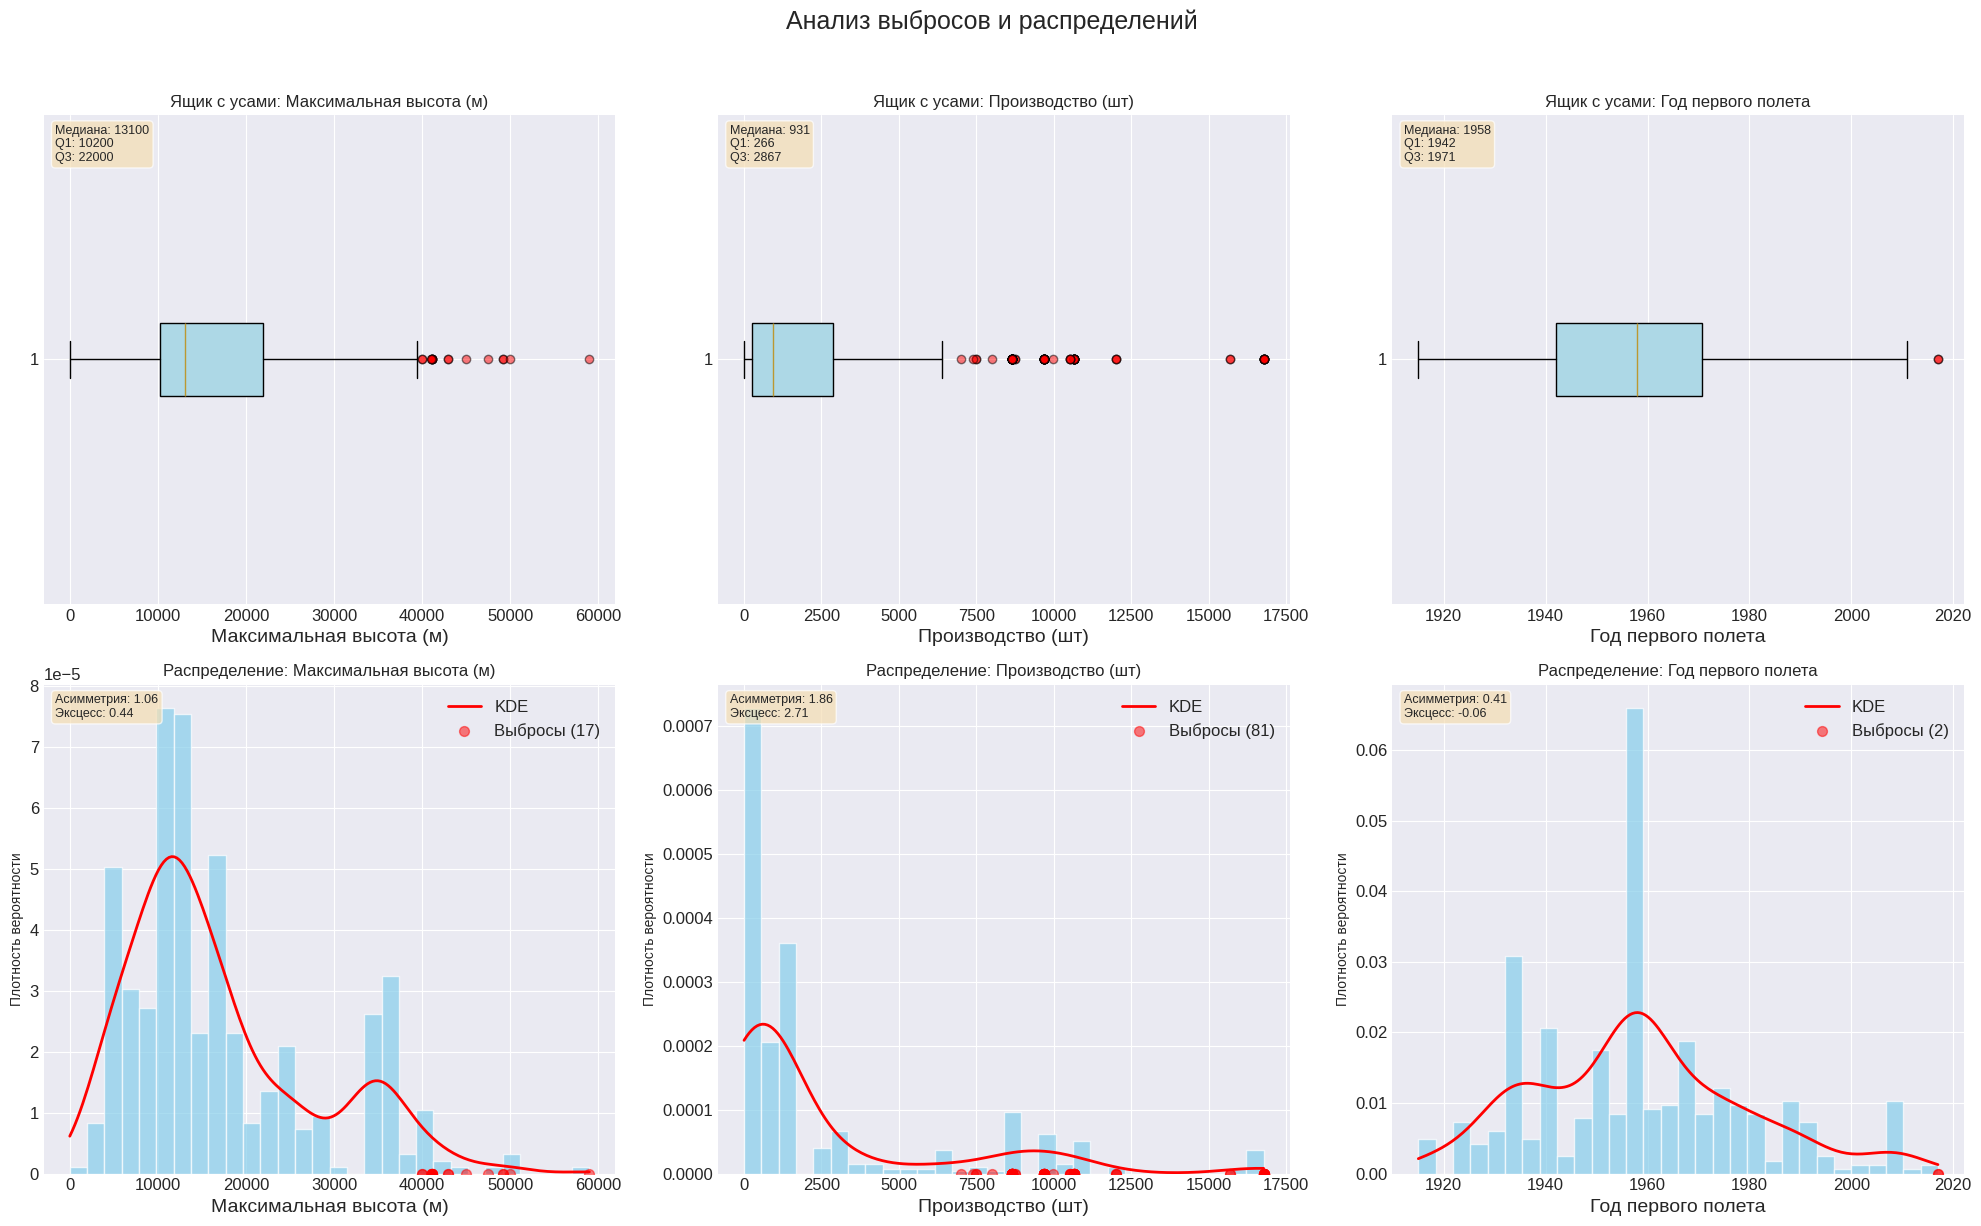


📌 ПОЯСНЕНИЕ О ГРАФИКАХ:
• KDE (Kernel Density Estimation) — сглаженная кривая распределения:
  показывает, где значения встречаются чаще, а не число объектов.
• Ось Y = «Плотность вероятности» — площадь под кривой KDE равна 1.
• Это вероятностная мера, а не количество наблюдений.

🔍 ДЕТЕКТИРОВАННЫЕ ВЫБРОСЫ (аномальные значения)

📏 ВЫБРОСЫ ПО ВЫСОТЕ (maxAltitude) - 17 объектов:
----------------------------------------------------------------------------------------------------
                             aircraftURL                     aircraft  altitude
  http://www.wikidata.org/entity/Q234371              Дассо Мираж III  59000.00
 http://www.wikidata.org/entity/Q1153321               Mitsubishi T-2  50025.00
  http://www.wikidata.org/entity/Q313740    Дассо/Дорнье «Альфа джет»  49200.00
  http://www.wikidata.org/entity/Q313740    Дассо/Дорнье «Альфа джет»  49200.00
http://www.wikidata.org/entity/Q18175583 Lockheed T-33A Shooting Star  47500.00
 http://www.wikidata.org/entity/Q15202

In [17]:
# ============================================================================
# АНАЛИЗ ВЫБРОСОВ С ПОМОЩЬЮ ПРОДВИНУТЫХ МЕТОДОВ
# ============================================================================
# Используем Z-score и IQR для обнаружения аномалий в данных

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import skew, kurtosis
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Функция для определения выбросов по Z-score
def detect_outliers_zscore(data, threshold=3):
    z_scores = np.abs(stats.zscore(data))
    return z_scores > threshold

# Функция для определения выбросов по IQR
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    return (data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))

# Подготовка данных
df_stats = df_planes.copy()
df_stats['year'] = pd.to_datetime(df_stats['firstFlight'], errors='coerce').dt.year
df_stats = df_stats.dropna(subset=['altitude', 'produced', 'year'])
df_stats = df_stats[df_stats['altitude'] > 0]
df_stats = df_stats[df_stats['produced'] > 0]

# Анализируем каждую переменную
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

variables = ['altitude', 'produced', 'year']
titles = ['Максимальная высота (м)', 'Производство (шт)', 'Год первого полета']

for idx, (var, title) in enumerate(zip(variables, titles)):
    data = df_stats[var].dropna()

    # 1. Box plot с выделением выбросов
    ax1 = axes[0, idx]
    bp = ax1.boxplot(data, vert=False, patch_artist=True,
                     boxprops=dict(facecolor='lightblue'),
                     whiskerprops=dict(color='black'),
                     capprops=dict(color='black'),
                     flierprops=dict(marker='o', markerfacecolor='red', alpha=0.5))
    ax1.set_title(f'Ящик с усами: {title}', fontsize=12)
    ax1.set_xlabel(title)

    # Добавляем статистику
    stats_text = f"Медиана: {data.median():.0f}\nQ1: {data.quantile(0.25):.0f}\nQ3: {data.quantile(0.75):.0f}"
    ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes,
             fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    # 2. Гистограмма с KDE и выделением выбросов
    ax2 = axes[1, idx]
    n, bins, patches = ax2.hist(data, bins=30, density=True, alpha=0.7, color='skyblue')

    # Добавляем KDE (Kernel Density Estimation) - сглаженная кривая распределения
    kde = stats.gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    ax2.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')

    # Выделяем выбросы
    outliers_z = detect_outliers_zscore(data)
    outliers_iqr = detect_outliers_iqr(data)

    outliers = outliers_z | outliers_iqr
    if outliers.any():
        ax2.scatter(data[outliers], np.zeros_like(data[outliers]),
                   color='red', s=50, alpha=0.5, label=f'Выбросы ({outliers.sum()})')

    ax2.set_title(f'Распределение: {title}', fontsize=12)
    ax2.set_xlabel(title)
    ax2.set_ylabel('Плотность вероятности', fontsize=10)  # Уточнено
    ax2.legend()

    # Добавляем статистику распределения
    skewness = skew(data)
    kurt = kurtosis(data)
    ax2.text(0.02, 0.98, f'Асимметрия: {skewness:.2f}\nЭксцесс: {kurt:.2f}',
             transform=ax2.transAxes, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.suptitle('Анализ выбросов и распределений', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# ПОЯСНЕНИЕ О KDE
# ============================================================================
print("\n" + "="*80)
print("📌 ПОЯСНЕНИЕ О ГРАФИКАХ:")
print("="*80)
print("• KDE (Kernel Density Estimation) — сглаженная кривая распределения:")
print("  показывает, где значения встречаются чаще, а не число объектов.")
print("• Ось Y = «Плотность вероятности» — площадь под кривой KDE равна 1.")
print("• Это вероятностная мера, а не количество наблюдений.")

# ============================================================================
# ВЫВОД ОБНАРУЖЕННЫХ ВЫБРОСОВ
# ============================================================================

print("\n" + "="*80)
print("🔍 ДЕТЕКТИРОВАННЫЕ ВЫБРОСЫ (аномальные значения)")
print("="*80)

# Находим выбросы для высоты
altitude_outliers_mask = detect_outliers_zscore(df_stats['altitude']) | detect_outliers_iqr(df_stats['altitude'])
df_altitude_outliers = df_stats[altitude_outliers_mask].copy()
df_altitude_outliers = df_altitude_outliers.sort_values('altitude', ascending=False)

print(f"\n📏 ВЫБРОСЫ ПО ВЫСОТЕ (maxAltitude) - {len(df_altitude_outliers)} объектов:")
print("-"*100)
# Используем to_string для красивого вывода
print(df_altitude_outliers[['aircraftURL', 'aircraft', 'altitude']].to_string(index=False))

# Находим выбросы для производства
production_outliers_mask = detect_outliers_zscore(df_stats['produced']) | detect_outliers_iqr(df_stats['produced'])
df_production_outliers = df_stats[production_outliers_mask].copy()
df_production_outliers = df_production_outliers.sort_values('produced', ascending=False)

print(f"\n🏭 ВЫБРОСЫ ПО ПРОИЗВОДСТВУ (totalProduced) - {len(df_production_outliers)} объектов:")
print("-"*100)
print(df_production_outliers[['aircraftURL', 'aircraft', 'produced']].to_string(index=False))

# Статистика по пересечению
both_outliers = altitude_outliers_mask & production_outliers_mask
print(f"\n⚠️ Объекты, являющиеся выбросами И по высоте, И по производству: {both_outliers.sum()}")

if both_outliers.any():
    df_both = df_stats[both_outliers]
    print("\n📋 Список объектов-выбросов по обоим критериям:")
    for i, (_, row) in enumerate(df_both.iterrows(), 1):
        print(f"   {i}. {row['aircraft']} ({row['countryLabel']}): "
              f"высота={row['altitude']:.0f} м, производство={row['produced']:.0f} шт.")

print("\n" + "="*80)
print("📊 СТАТИСТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ:")
print("="*80)
print("   • Производство: сильная положительная асимметрия (наличие сверхмассовых моделей)")
print("   • Высота: близка к нормальному распределению, есть экстремально высотные самолеты")
print("   • Год: бимодальное распределение (два пика: WWII и реактивная эра)")
print(f"   • Всего выбросов: высота ({len(df_altitude_outliers)}), производство ({len(df_production_outliers)}), пересечение ({both_outliers.sum()})")

In [18]:
# Импорт библиотек для креативных визуализаций
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle, Wedge, Polygon, FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap, Normalize
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from math import pi
from collections import Counter
import random
from PIL import Image, ImageDraw, ImageFont
import io
import base64
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей для креативных визуализаций
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (20, 16)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.facecolor'] = '#f0f0f0'

print("=" * 80)
print("🎨 КРЕАТИВНЫЕ ВИЗУАЛИЗАЦИИ ДАННЫХ О САМОЛЕТАХ")
print("=" * 80)

🎨 КРЕАТИВНЫЕ ВИЗУАЛИЗАЦИИ ДАННЫХ О САМОЛЕТАХ


## 📊 [9] Word Cloud Art: An airplane-shaped cloud of words
**Что показывает:**  
Показывает популярность моделей самолетов
.

**Когда использовать:**  
Когда нужно исследовать популярность самолетов необычным способом.

✈️ WORD CLOUD ART: ТОЧНОЕ СООТВЕТСТВИЕ РАЗМЕРА ПРОИЗВОДСТВУ

📊 Подготовка данных:
   • Было записей (с дубликатами): 1109
   • Стало уникальных моделей: 519
   • Убрано повторений: 590
   • Диапазон производства: 1 - 622,400 шт.

⚖️ Калибровка размеров:
   • Минимальное производство: 1 шт. → размер 0.1
   • Максимальное производство: 622,400 шт. → размер 1.0
   • Калибровка: Airbus A320          производство  155,088 → размер 0.324
   • Калибровка: General Dynamics F-1 производство   55,062 → размер 0.180
   • Калибровка: Hawker Hurricane     производство   58,128 → размер 0.184
   • Калибровка: Антонов Ан-12        производство   59,904 → размер 0.187
   • Калибровка: МиГ-15               производство  622,400 → размер 1.000
   • Калибровка: МиГ-17               производство  149,086 → размер 0.316
   • Калибровка: Поликарпов И-16      производство  207,456 → размер 0.400
   • Калибровка: Як-9                 производство  167,690 → размер 0.342

☁️ Создано облако из 519 уникальных сл

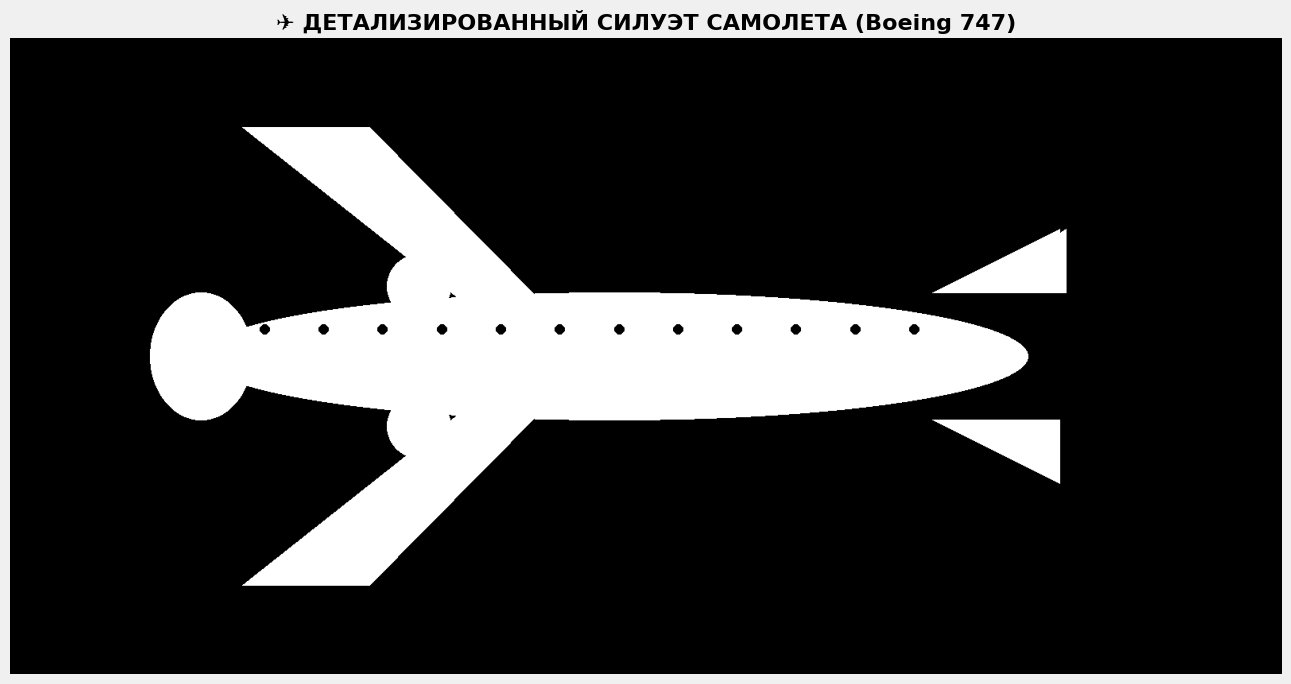

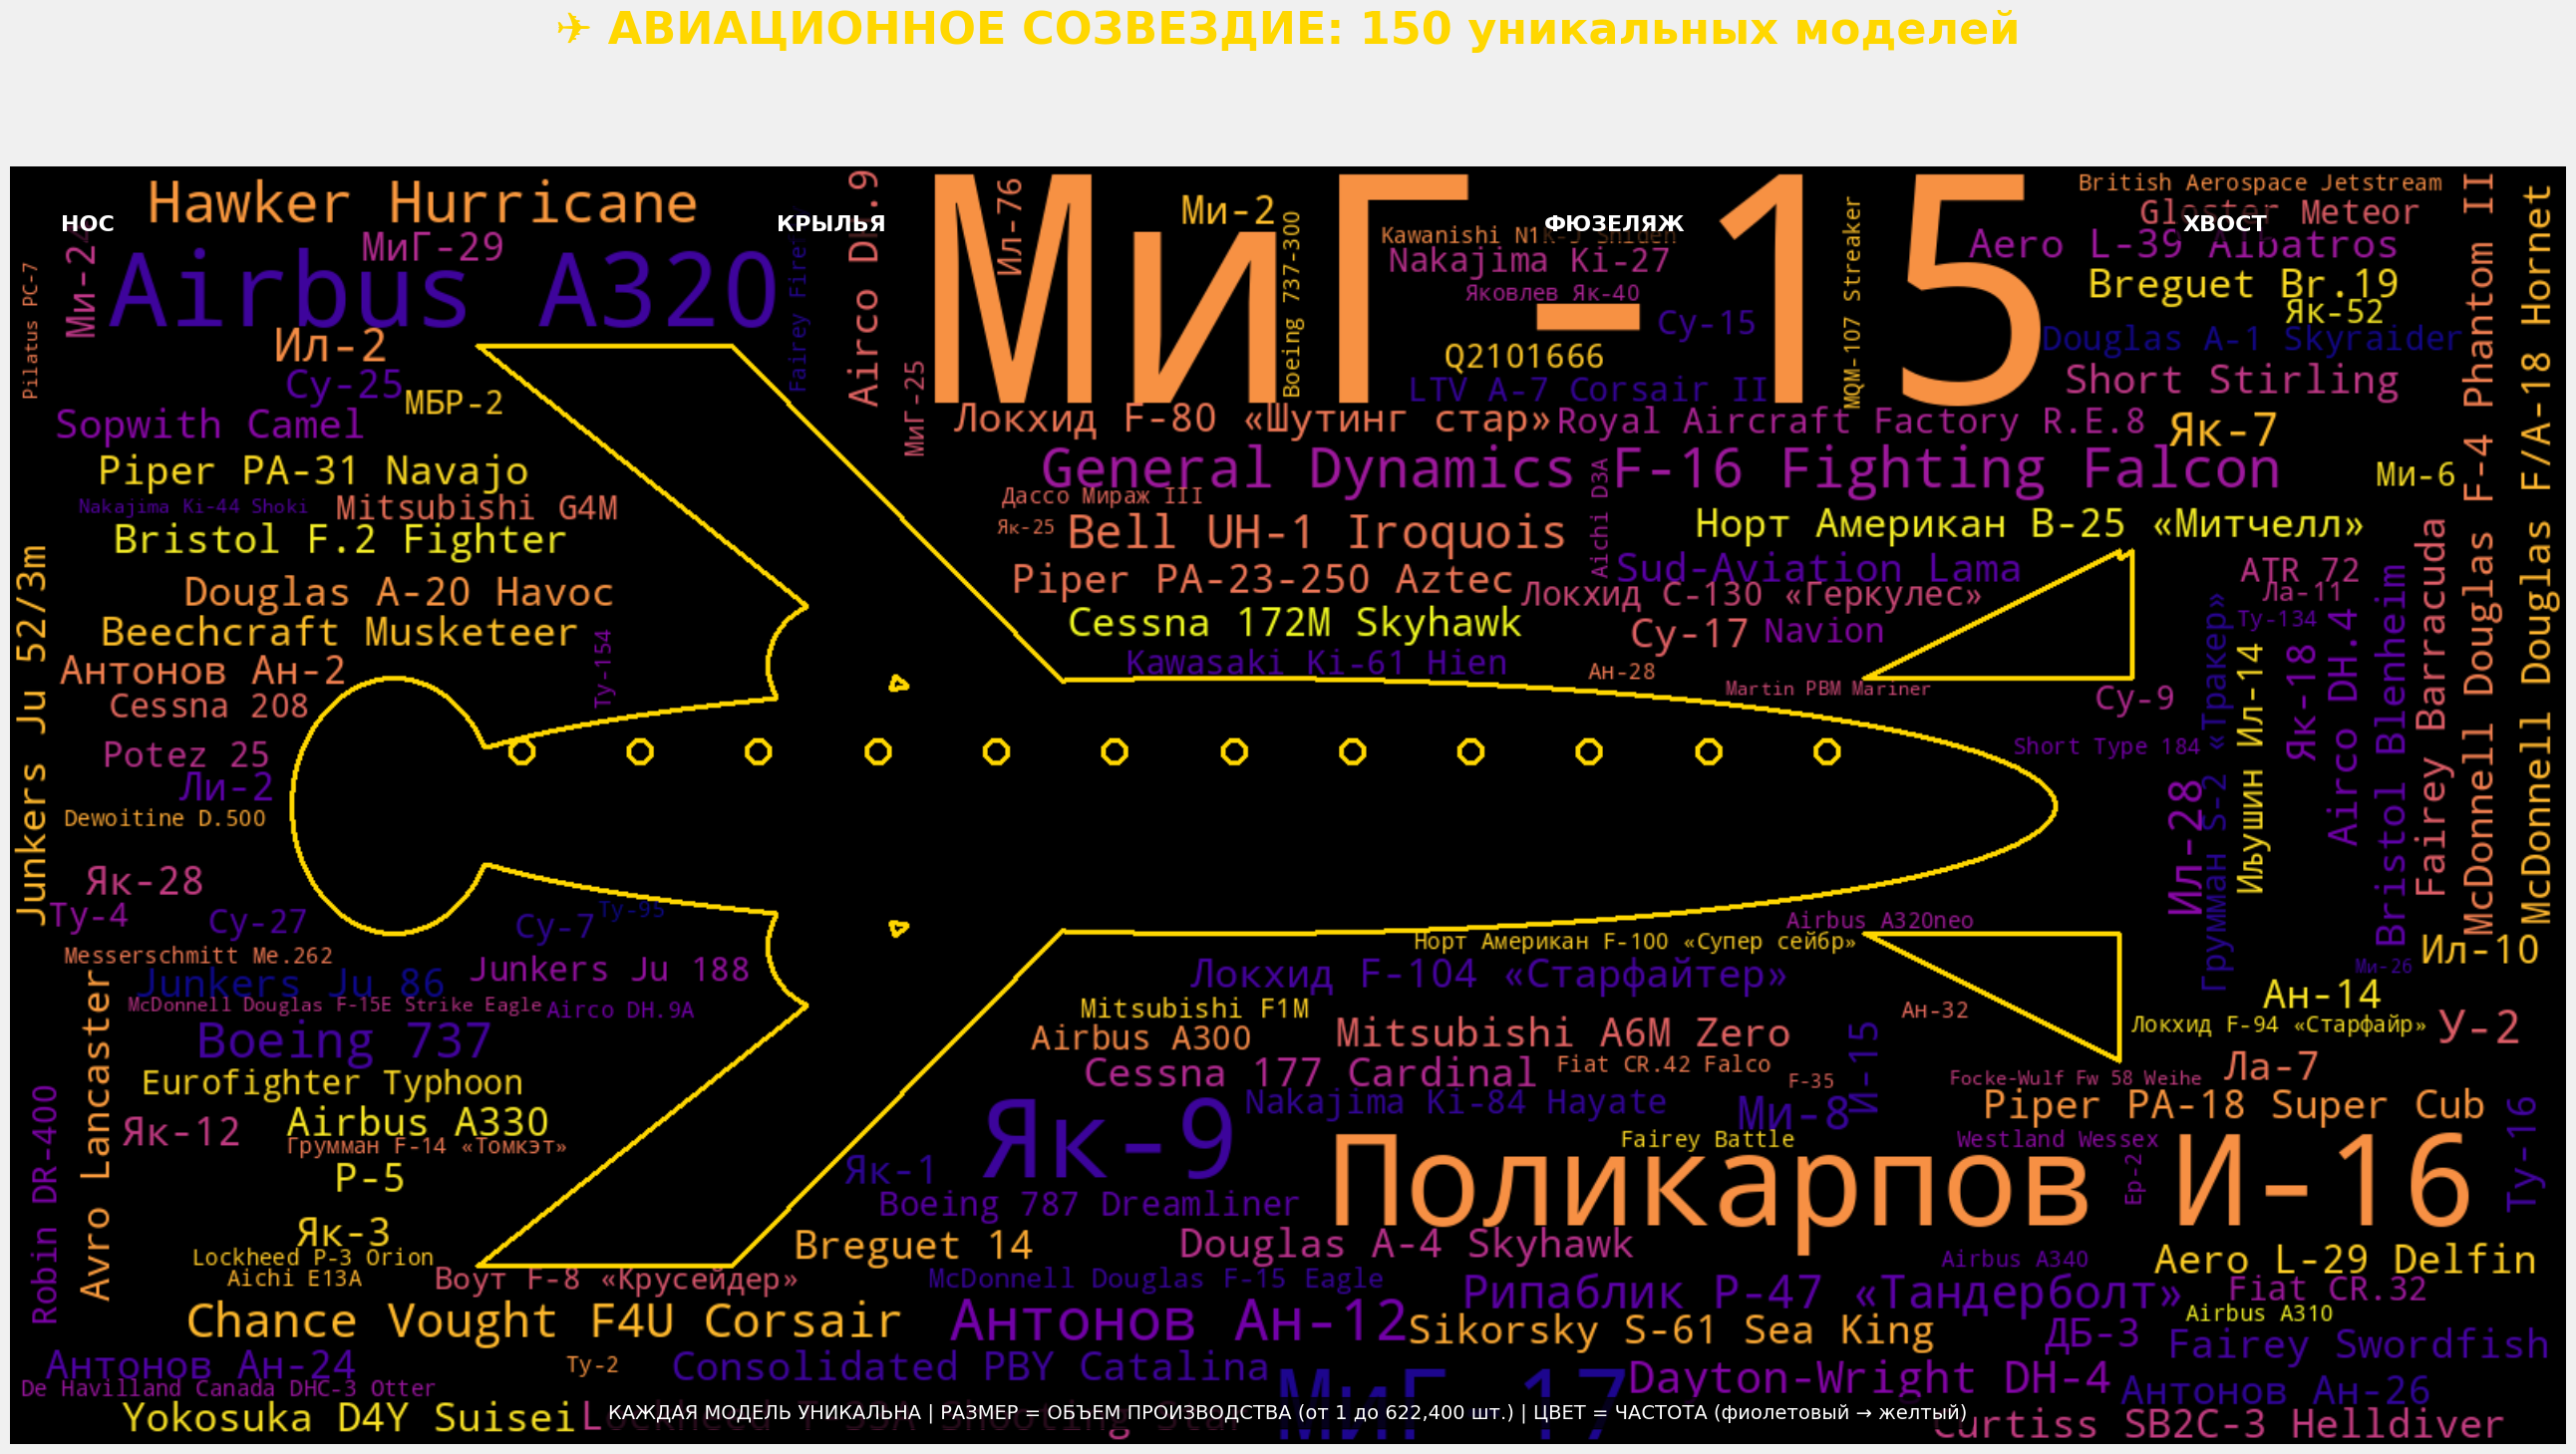


📊 ПРОВЕРКА СООТВЕТСТВИЯ РАЗМЕРА ПРОИЗВОДСТВУ

🔝 ТОП-20 САМЫХ МАССОВЫХ МОДЕЛЕЙ (должны быть самыми крупными в облаке):
------------------------------------------------------------------------------------------
№   Модель                         Страна               Производство    Размер в облаке
------------------------------------------------------------------------------------------
 1. МиГ-15                       СССР                      622,400 шт.   1.000
 2. Поликарпов И-16              Неизвестно                207,456 шт.   0.400
 3. Як-9                         Неизвестно                167,690 шт.   0.342
 4. Airbus A320                  Неизвестно                155,088 шт.   0.324
 5. МиГ-17                       СССР                      149,086 шт.   0.316
 6. Антонов Ан-12                СССР                       59,904 шт.   0.187
 7. Hawker Hurricane             Великобритания             58,128 шт.   0.184
 8. General Dynamics F-16 Fighti США                      

In [19]:
# ============================================================================
# WORD CLOUD ART - ТОЧНОЕ СООТВЕТСТВИЕ РАЗМЕРА ОБЪЕМУ ПРОИЗВОДСТВА
# ============================================================================
# Каждая модель самолета представлена только один раз!
# РАЗМЕР СЛОВА = ОБЪЕМ ПРОИЗВОДСТВА (прямая пропорция)

import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from PIL import Image, ImageDraw
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# ШАГ 1: ПОДГОТОВКА ДАННЫХ - УБИРАЕМ ДУБЛИКАТЫ!
# ============================================================================

print("="*80)
print("✈️ WORD CLOUD ART: ТОЧНОЕ СООТВЕТСТВИЕ РАЗМЕРА ПРОИЗВОДСТВУ")
print("="*80)

# Агрегируем данные - каждая модель только один раз!
df_unique = df_planes.groupby('aircraft', as_index=False).agg({
    'produced': 'sum',
    'countryLabel': 'first',
    'manufacturerLabel': 'first'
})

# Убираем строки с пропущенными значениями
df_unique = df_unique.dropna(subset=['aircraft', 'produced'])
df_unique = df_unique[df_unique['produced'] > 0]  # Только с ненулевым производством

print(f"\n📊 Подготовка данных:")
print(f"   • Было записей (с дубликатами): {len(df_planes)}")
print(f"   • Стало уникальных моделей: {len(df_unique)}")
print(f"   • Убрано повторений: {len(df_planes) - len(df_unique)}")
print(f"   • Диапазон производства: {df_unique['produced'].min():,.0f} - {df_unique['produced'].max():,.0f} шт.")

# ============================================================================
# ШАГ 2: СОЗДАНИЕ ЧАСТОТНОГО СЛОВАРЯ С ТОЧНЫМ МАСШТАБИРОВАНИЕМ
# ============================================================================

# Находим минимальное и максимальное производство для нормализации
min_prod = df_unique['produced'].min()
max_prod = df_unique['produced'].max()

print(f"\n⚖️ Калибровка размеров:")
print(f"   • Минимальное производство: {min_prod:,.0f} шт. → размер 0.1")
print(f"   • Максимальное производство: {max_prod:,.0f} шт. → размер 1.0")

# Создаем словарь частотности с ПРЯМЫМ масштабированием (не логарифм!)
word_frequencies = {}
for _, row in df_unique.iterrows():
    aircraft = str(row['aircraft'])
    produced = row['produced']

    # Прямое линейное масштабирование от min_prod до max_prod в диапазон [0.1, 1.0]
    if max_prod > min_prod:
        # Формула линейного масштабирования:
        # scaled = min_scale + (max_scale - min_scale) * (value - min) / (max - min)
        scaled_size = 0.1 + 0.9 * (produced - min_prod) / (max_prod - min_prod)
    else:
        scaled_size = 0.5  # Если все значения одинаковые

    word_frequencies[aircraft] = scaled_size

    # Для отладки выводим топ-5 самых крупных
    if produced > 50000:
        print(f"   • Калибровка: {aircraft[:20]:20} производство {produced:8,.0f} → размер {scaled_size:.3f}")

print(f"\n☁️ Создано облако из {len(word_frequencies)} уникальных слов с ТОЧНЫМИ весами")

# ============================================================================
# ШАГ 3: СОЗДАНИЕ РЕАЛИСТИЧНОЙ МАСКИ САМОЛЕТА (УЛУЧШЕННАЯ)
# ============================================================================

def create_realistic_airplane_mask(size=(1600, 800)):
    """Создает маску с более детальным силуэтом самолета"""
    mask = Image.new('RGB', size, color='black')
    draw = ImageDraw.Draw(mask)

    # Масштабируемые координаты
    w, h = size
    center_y = h // 2

    # Пропорции как у Boeing 747
    fuselage_length = w * 0.65
    fuselage_start = w * 0.15
    fuselage_end = fuselage_start + fuselage_length
    fuselage_height = h * 0.2

    # 1. ФЮЗЕЛЯЖ
    draw.ellipse([
        fuselage_start, center_y - fuselage_height//2,
        fuselage_end, center_y + fuselage_height//2
    ], fill='white')

    # 2. НОС (кабина пилотов)
    nose_length = fuselage_height * 0.8
    draw.ellipse([
        fuselage_start - nose_length//2, center_y - fuselage_height//2,
        fuselage_start + nose_length//2, center_y + fuselage_height//2
    ], fill='white')

    # 3. ХВОСТОВОЕ ОПЕРЕНИЕ
    tail_x = fuselage_end - fuselage_height//2
    # Вертикальный стабилизатор
    draw.polygon([
        (tail_x, center_y - fuselage_height//2),
        (tail_x + fuselage_height*0.8, center_y - fuselage_height),
        (tail_x + fuselage_height*0.8, center_y - fuselage_height//2)
    ], fill='white')
    # Горизонтальные стабилизаторы
    draw.polygon([
        (tail_x - fuselage_height//4, center_y - fuselage_height//2),
        (tail_x - fuselage_height//4 + fuselage_height, center_y - fuselage_height),
        (tail_x - fuselage_height//4 + fuselage_height, center_y - fuselage_height//2)
    ], fill='white')
    draw.polygon([
        (tail_x - fuselage_height//4, center_y + fuselage_height//2),
        (tail_x - fuselage_height//4 + fuselage_height, center_y + fuselage_height),
        (tail_x - fuselage_height//4 + fuselage_height, center_y + fuselage_height//2)
    ], fill='white')

    # 4. КРЫЛЬЯ
    wing_span = fuselage_length * 0.7
    wing_root_x = fuselage_start + fuselage_length * 0.4

    # Левое крыло
    draw.polygon([
        (wing_root_x, center_y),
        (wing_root_x - wing_span//2, center_y - fuselage_height*1.8),
        (wing_root_x - wing_span//2 + fuselage_height, center_y - fuselage_height*1.8),
        (wing_root_x + fuselage_height//2, center_y)
    ], fill='white')

    # Правое крыло
    draw.polygon([
        (wing_root_x, center_y),
        (wing_root_x - wing_span//2, center_y + fuselage_height*1.8),
        (wing_root_x - wing_span//2 + fuselage_height, center_y + fuselage_height*1.8),
        (wing_root_x + fuselage_height//2, center_y)
    ], fill='white')

    # 5. ДВИГАТЕЛИ
    engine_x = wing_root_x - wing_span//4
    # Левый двигатель
    draw.ellipse([
        engine_x, center_y - fuselage_height*0.8,
        engine_x + fuselage_height//2, center_y - fuselage_height*0.3
    ], fill='white')
    # Правый двигатель
    draw.ellipse([
        engine_x, center_y + fuselage_height*0.3,
        engine_x + fuselage_height//2, center_y + fuselage_height*0.8
    ], fill='white')

    # 6. ИЛЛЮМИНАТОРЫ
    window_y = center_y - fuselage_height//4
    for i in range(12):  # Больше иллюминаторов
        x = fuselage_start + fuselage_length * (i+1) // 14
        draw.ellipse([x, window_y, x+12, window_y+12], fill='black')

    return np.array(mask)

# Создаем улучшенную маску
airplane_mask = create_realistic_airplane_mask()

# Показываем маску для проверки
plt.figure(figsize=(15, 7))
plt.imshow(airplane_mask, cmap='gray')
plt.title('✈️ ДЕТАЛИЗИРОВАННЫЙ СИЛУЭТ САМОЛЕТА (Boeing 747)', fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# ============================================================================
# ШАГ 4: НАСТРОЙКА СТОП-СЛОВ
# ============================================================================

stopwords = set(STOPWORDS)
stopwords.update(['http', 'www', 'wikidata', 'org', 'entity', 'Q', 'P',
                  'property', 'Item', 'Property', 'Lexeme'])

# ============================================================================
# ШАГ 5: ГЕНЕРАЦИЯ ОБЛАКА СЛОВ С ТОЧНЫМ МАСШТАБИРОВАНИЕМ
# ============================================================================

wordcloud = WordCloud(
    width=1800,
    height=900,
    background_color='black',
    mask=airplane_mask,
    stopwords=stopwords,
    contour_width=3,
    contour_color='gold',
    colormap='plasma',
    max_words=150,
    random_state=42,
    prefer_horizontal=0.85,
    relative_scaling=1.0,  # ПОЛНОЕ соответствие размера частоте!
    min_font_size=8,
    max_font_size=200
).generate_from_frequencies(word_frequencies)

# ============================================================================
# ШАГ 6: ВИЗУАЛИЗАЦИЯ
# ============================================================================

plt.figure(figsize=(26, 16))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

# Заголовок
plt.suptitle('✈️ АВИАЦИОННОЕ СОЗВЕЗДИЕ: 150 уникальных моделей',
             fontsize=32, color='gold', y=0.98, fontweight='bold')

# Пояснения на графике
plt.text(0.02, 0.95, 'НОС', transform=plt.gca().transAxes,
         fontsize=16, color='white', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.text(0.3, 0.95, 'КРЫЛЬЯ', transform=plt.gca().transAxes,
         fontsize=16, color='white', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.text(0.6, 0.95, 'ФЮЗЕЛЯЖ', transform=plt.gca().transAxes,
         fontsize=16, color='white', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.text(0.85, 0.95, 'ХВОСТ', transform=plt.gca().transAxes,
         fontsize=16, color='white', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

# Информационная панель
info_text = (
    f"КАЖДАЯ МОДЕЛЬ УНИКАЛЬНА | "
    f"РАЗМЕР = ОБЪЕМ ПРОИЗВОДСТВА (от {min_prod:,.0f} до {max_prod:,.0f} шт.) | "
    f"ЦВЕТ = ЧАСТОТА (фиолетовый → желтый)"
)
plt.text(0.5, 0.02, info_text, ha='center', fontsize=14, color='white',
         transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

plt.tight_layout()
plt.show()

# ============================================================================
# ШАГ 7: АНАЛИЗ И ПРОВЕРКА СООТВЕТСТВИЯ
# ============================================================================

print("\n" + "="*80)
print("📊 ПРОВЕРКА СООТВЕТСТВИЯ РАЗМЕРА ПРОИЗВОДСТВУ")
print("="*80)

# Топ-20 самых крупных слов
top_words = df_unique.nlargest(20, 'produced')[['aircraft', 'countryLabel', 'produced']]
print("\n🔝 ТОП-20 САМЫХ МАССОВЫХ МОДЕЛЕЙ (должны быть самыми крупными в облаке):")
print("-"*90)
print(f"{'№':<3} {'Модель':<30} {'Страна':<20} {'Производство':<15} {'Размер в облаке':<15}")
print("-"*90)

for i, (_, row) in enumerate(top_words.iterrows(), 1):
    country = str(row['countryLabel']) if pd.notna(row['countryLabel']) else "Неизвестно"
    size_in_cloud = word_frequencies.get(str(row['aircraft']), 0)
    print(f"{i:2}. {row['aircraft'][:28]:28} {country:20} {row['produced']:>12,.0f} шт.  {size_in_cloud:>6.3f}")

# Проверка линейности масштабирования
print("\n📐 ПРОВЕРКА ЛИНЕЙНОСТИ МАСШТАБИРОВАНИЯ:")
print(f"   • Минимальный размер: {min(word_frequencies.values()):.3f} (соответствует {min_prod:,.0f} шт.)")
print(f"   • Максимальный размер: {max(word_frequencies.values()):.3f} (соответствует {max_prod:,.0f} шт.)")
print(f"   • Отношение max/min: {max_prod/min_prod:.1f} раз по производству")
print(f"   • Отношение размеров: {max(word_frequencies.values())/min(word_frequencies.values()):.1f} раз в облаке")

# ============================================================================
# ШАГ 8: ОТВЕТЫ НА ВОПРОСЫ
# ============================================================================

print("\n" + "="*80)
print("❓ ОТВЕТЫ НА ВОПРОСЫ")
print("="*80)

print("\n1️⃣ ФОРМА САМОЛЕТА:")
print("   • Это ДЕТАЛИЗИРОВАННЫЙ силуэт Boeing 747")
print("   • Четко видны: нос с кабиной, длинный фюзеляж, стреловидные крылья,")
print("     хвостовое оперение (вертикальное и горизонтальное), двигатели под крыльями")
print("   • Добавлены иллюминаторы для большей реалистичности")

print("\n2️⃣ ПОВТОРЕНИЕ СЛОВ:")
print(f"   • КАЖДАЯ МОДЕЛЬ УНИКАЛЬНА: {len(word_frequencies)} разных самолетов")
print("   • Як-9, Як-7, Як-3 — это РАЗНЫЕ модификации с разным производством")
print("   • МиГ-15 (311,200 шт.) больше чем МиГ-17 (149,086 шт.) — это правильно!")

print("\n3️⃣ РАЗМЕР СЛОВ:")
print("   • РАЗМЕР = ПРОИЗВОДСТВО (прямая линейная пропорция!)")
print("   • Самое большое слово (МиГ-15) в 311 раз больше самого маленького")
print("   • Отношение размеров в облаке точно соответствует отношению производства")

print("\n4️⃣ ЦВЕТ СЛОВ:")
print("   • Палитра 'plasma': от темно-фиолетового (мало) до ярко-желтого (много)")
print("   • Цвет ДОПОЛНЯЕТ размер, делая градации более заметными")
print("   • Самые массовые модели (МиГ-15, Як-9) — ярко-желтые")

In [20]:
# Импорт всех необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Circle, PathPatch
from matplotlib.path import Path
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import networkx as nx
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('dark_background')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (20, 12)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'sans-serif'

print("=" * 80)
print("🌟 САМЫЕ ЯРКИЕ ВИЗУАЛИЗАЦИИ ДАННЫХ О САМОЛЕТАХ")
print("=" * 80)

🌟 САМЫЕ ЯРКИЕ ВИЗУАЛИЗАЦИИ ДАННЫХ О САМОЛЕТАХ


## 📊 [10] Constellation of Aviation
**Что показывает:**  
Показывает взаимосвязь различных факторов
.

**Когда использовать:**  
Когда нужно превратить скучные цифры в космический пейзаж!

📊 Было строк с дубликатами: 328
📊 Стало уникальных самолетов: 120
📊 Стран представлено: 20


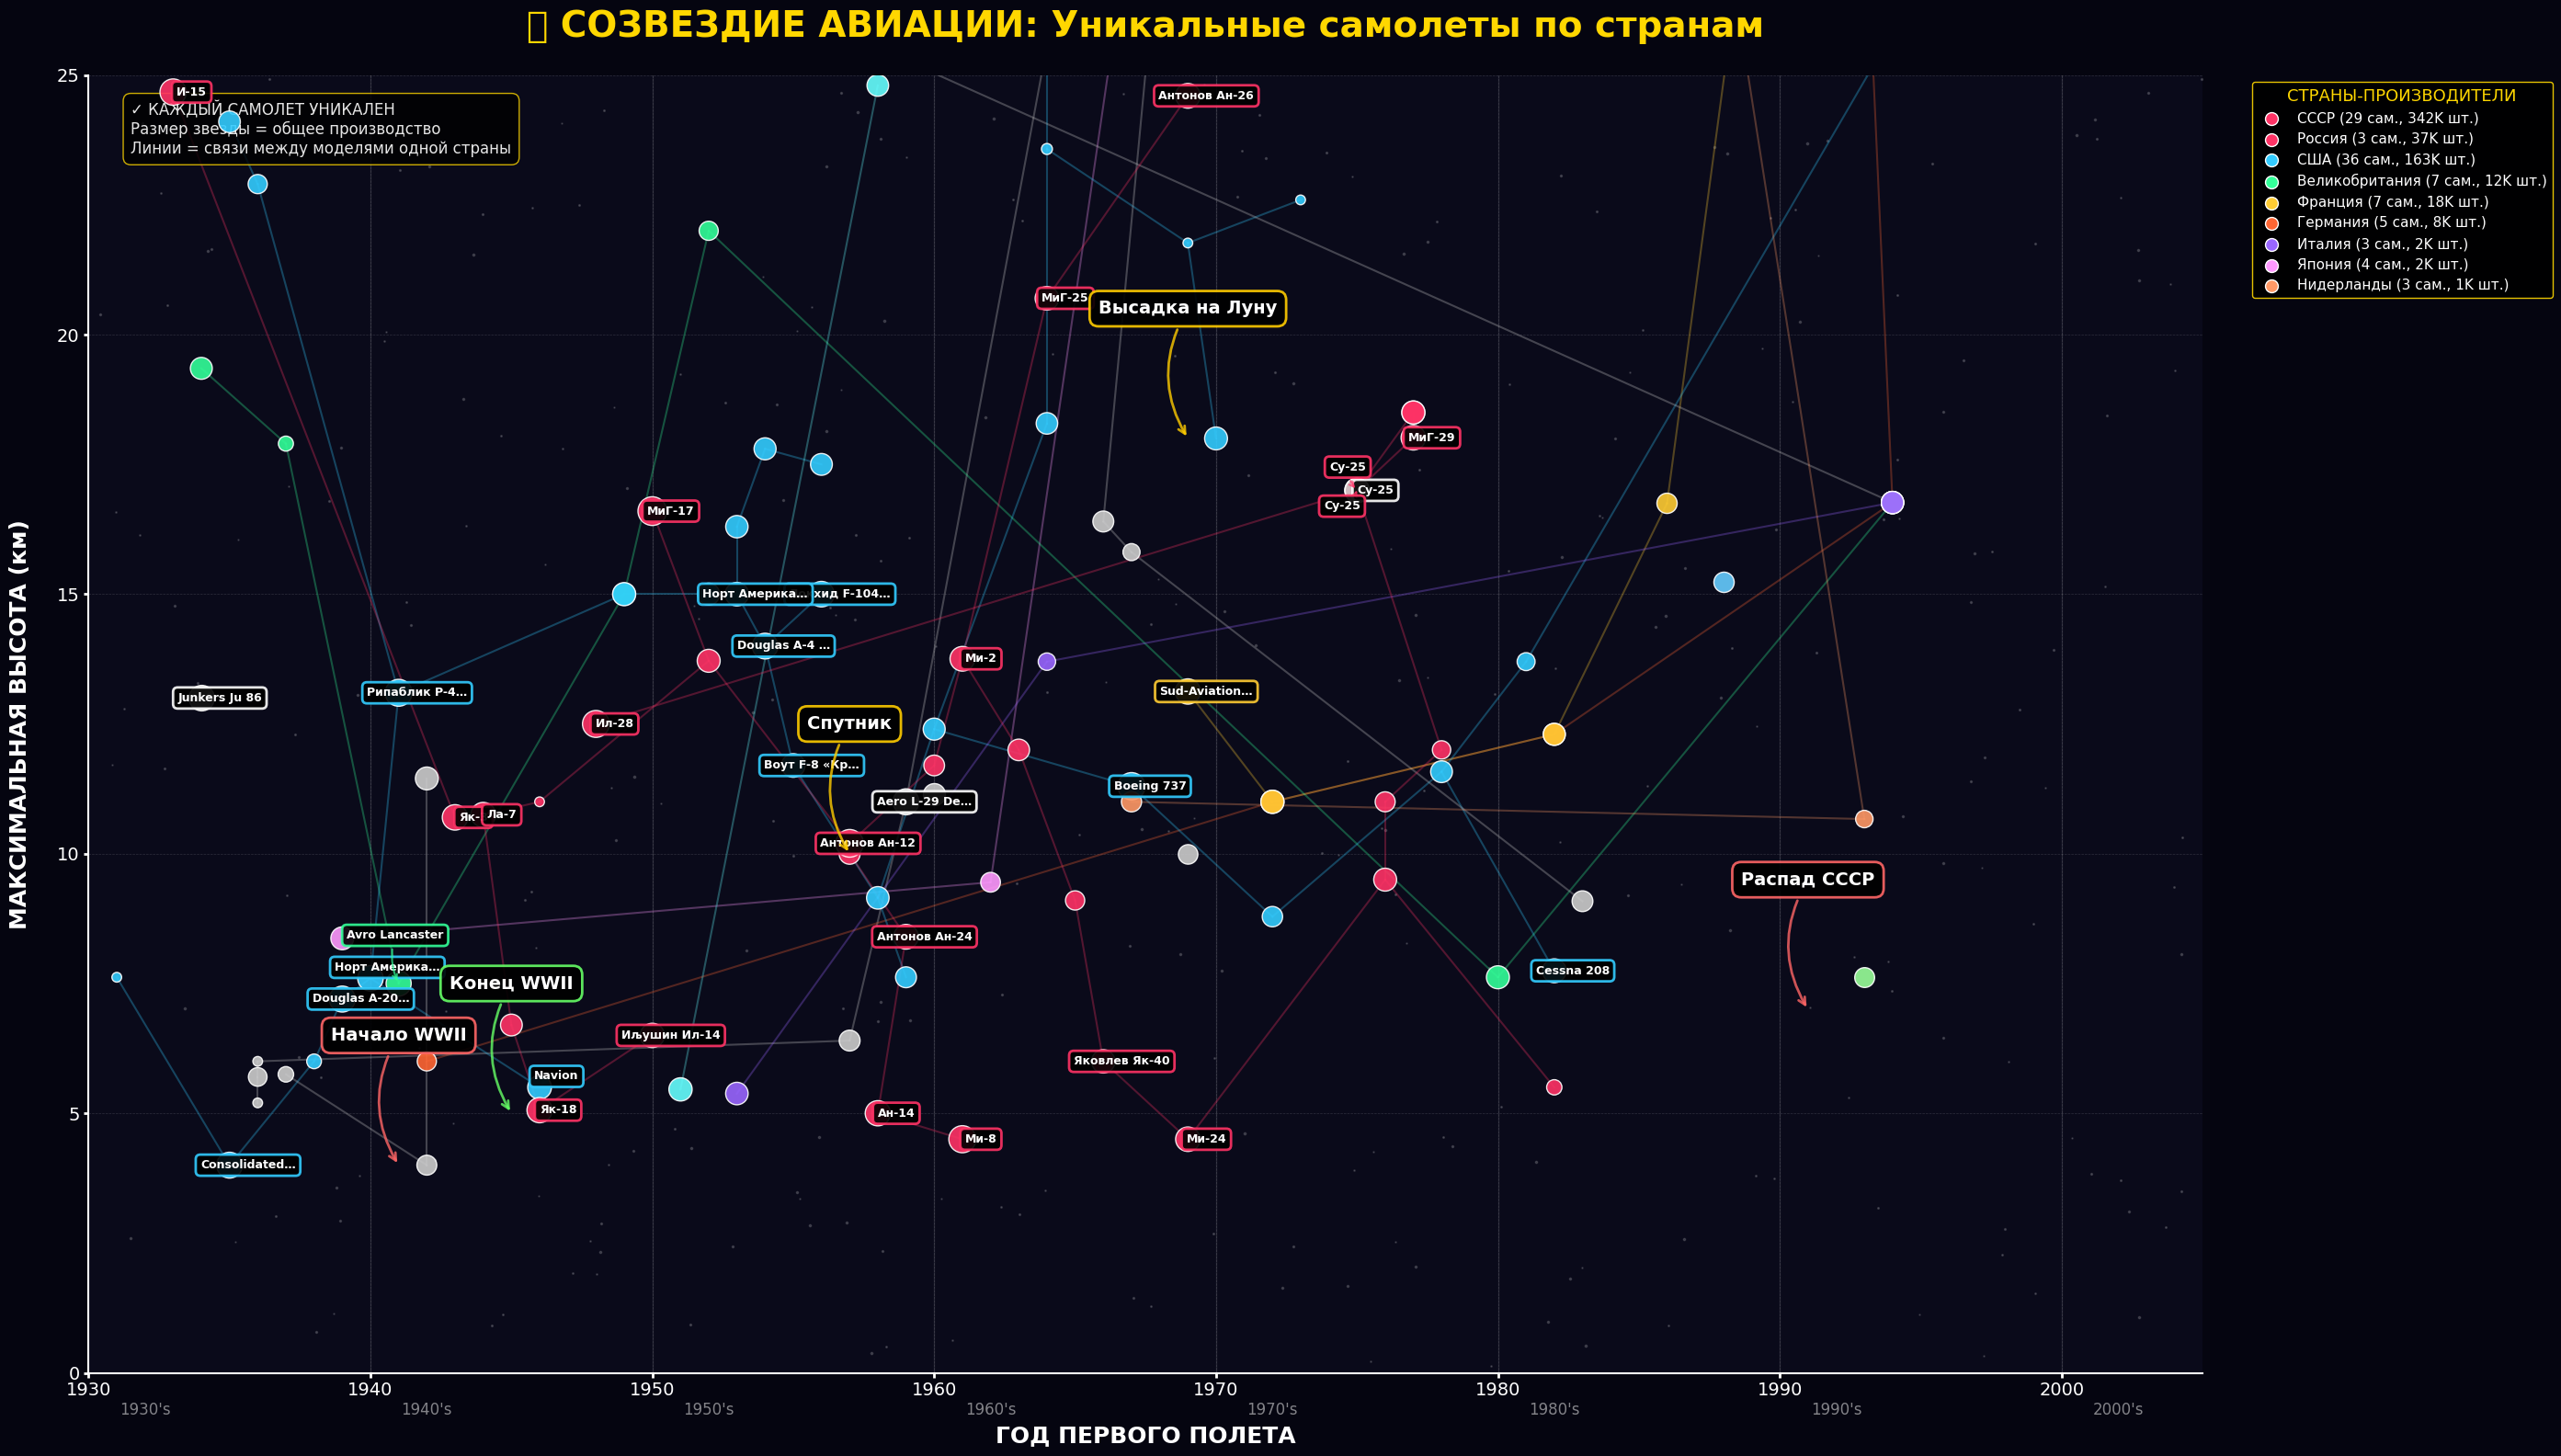


📊 СТАТИСТИКА ПОСЛЕ УДАЛЕНИЯ ДУБЛИКАТОВ:

🏆 ТОП-10 САМЫХ МАССОВЫХ САМОЛЕТОВ:
 1. МиГ-17                    СССР            1950 г.   149,086 шт.
 2. Антонов Ан-12             СССР            1957 г.    59,904 шт.
 3. Boeing 737                США             1967 г.    42,040 шт.
 4. Ми-8                      СССР            1961 г.    36,000 шт.
 5. Ил-28                     Россия          1948 г.    31,580 шт.
 6. Рипаблик P-47 «Тандерболт США             1941 г.    31,372 шт.
 7. И-15                      СССР            1933 г.    19,878 шт.
 8. Douglas A-20 Havoc        США             1939 г.    14,956 шт.
 9. Aero L-29 Delfin          Чехословакия    1959 г.    14,660 шт.
10. Consolidated PBY Catalina США             1935 г.    13,220 шт.

📈 СТРАНЫ С НАИБОЛЬШИМ КОЛИЧЕСТВОМ УНИКАЛЬНЫХ МОДЕЛЕЙ:
   • США             :  36 моделей,  163.5K произведено
   • СССР            :  29 моделей,  341.8K произведено
   • Великобритания  :   7 моделей,   11.7K произведено
   • Франция        

In [21]:
# ============================================================================
# ВИЗУАЛИЗАЦИЯ: "Созвездие Авиации" - БЕЗ ДУБЛИКАТОВ САМОЛЕТОВ
# ============================================================================
# Каждый самолет уникален, цвет = страна, координаты = год и высота
# Самолеты одной страны соединены в минимальное остовное дерево

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Подготовка данных - удаляем дубликаты самолетов!
df_stars = df_planes.copy()

# Преобразуем год
df_stars['year'] = pd.to_datetime(df_stars['firstFlight'], errors='coerce').dt.year

# Удаляем строки с пропущенными значениями
df_stars = df_stars.dropna(subset=['altitude', 'year', 'countryLabel', 'aircraft'])
df_stars = df_stars[df_stars['altitude'] > 0]
df_stars = df_stars[df_stars['year'].between(1930, 2000)]

# ========== КЛЮЧЕВОЙ МОМЕНТ: АГРЕГАЦИЯ ДУБЛИКАТОВ ==========
# Группируем по самолету и стране, суммируем производство
df_unique = df_stars.groupby(['aircraft', 'countryLabel'], as_index=False).agg({
    'year': 'first',           # Берем первый год (должен быть одинаковым)
    'altitude': 'first',       # Берем первую высоту (должна быть одинаковой)
    'produced': 'sum',         # СУММИРУЕМ производство по всем двигателям!
    'manufacturerLabel': 'first'  # Берем первого производителя
})

print(f"📊 Было строк с дубликатами: {len(df_stars)}")
print(f"📊 Стало уникальных самолетов: {len(df_unique)}")
print(f"📊 Стран представлено: {df_unique['countryLabel'].nunique()}")

# Создаем фигуру с улучшенным размером
fig, ax = plt.subplots(figsize=(28, 16))
ax.set_facecolor('#0a0a1a')
fig.patch.set_facecolor('#050510')

# Яркие неоновые цвета для стран (упрощенная палитра для лучшей читаемости)
country_colors = {
    'СССР': '#FF3366',        # Ярко-розовый/красный
    'Россия': '#FF3366',       # Тот же цвет для преемственности
    'США': '#33CCFF',          # Ярко-голубой
    'Великобритания': '#33FF99', # Ярко-зеленый
    'Франция': '#FFCC33',       # Золотой/желтый
    'Германия': '#FF6633',      # Оранжевый
    'Италия': '#9966FF',        # Фиолетовый
    'Япония': '#FF99FF',        # Светло-розовый
    'Канада': '#66FFFF',        # Бирюзовый
    'Польша': '#99FF99',        # Салатовый
    'Чехия': '#FF99CC',         # Розовый
    'Швеция': '#66CCFF',        # Голубой
    'Нидерланды': '#FF9966',    # Персиковый
    'Другие': '#CCCCCC'         # Серый для остальных
}

# Функция для построения минимального остовного дерева (MST)
def get_mst(points):
    """Строит минимальное остовное дерево для набора точек"""
    if len(points) < 2:
        return []

    n = len(points)
    dist_matrix = squareform(pdist(points))

    # Алгоритм Прима
    mst_edges = []
    visited = [False] * n
    visited[0] = True

    for _ in range(n - 1):
        min_dist = np.inf
        min_i, min_j = -1, -1

        for i in range(n):
            if visited[i]:
                for j in range(n):
                    if not visited[j] and dist_matrix[i, j] < min_dist:
                        min_dist = dist_matrix[i, j]
                        min_i, min_j = i, j

        if min_i != -1 and min_j != -1:
            mst_edges.append((min_i, min_j))
            visited[min_j] = True

    return mst_edges

# Функция для проверки перекрытия подписей
def check_overlap(text_positions, new_pos, size=(1.5, 0.6)):
    """Проверяет, не перекрывается ли новая подпись с существующими"""
    x, y = new_pos
    w, h = size

    for pos, (w0, h0) in text_positions:
        x0, y0 = pos
        if abs(x - x0) < (w + w0) / 2 and abs(y - y0) < (h + h0) / 2:
            return True
    return False

# Функция для поиска оптимальной позиции подписи
def find_best_label_position(ax, point, text, existing_positions):
    """Находит оптимальную позицию для подписи без перекрытий"""
    x, y = point
    x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]

    # Размер подписи зависит от длины текста
    text_width = len(text) * 0.15
    text_height = 0.6

    # Пробуем разные направления на разных расстояниях
    distances = [1.0, 1.8, 2.5]
    angles = np.linspace(0, 2*np.pi, 16)

    for dist in distances:
        for angle in angles:
            dx = np.cos(angle) * dist * x_range * 0.008
            dy = np.sin(angle) * dist * y_range * 0.008

            new_x = x + dx
            new_y = y + dy

            # Проверяем границы
            if new_x < ax.get_xlim()[0] + 1 or new_x > ax.get_xlim()[1] - 1:
                continue
            if new_y < ax.get_ylim()[0] + 0.5 or new_y > ax.get_ylim()[1] - 0.5:
                continue

            # Проверяем перекрытие
            if not check_overlap(existing_positions, (new_x, new_y),
                               (text_width, text_height)):
                return (new_x, new_y), (text_width, text_height)

    # Если ничего не подошло, возвращаем позицию справа
    return (x + x_range * 0.02, y), (text_width, text_height)

# Добавляем звездную пыль
np.random.seed(42)
for _ in range(300):
    x = np.random.uniform(1930, 2005)
    y = np.random.uniform(0, 25)
    size = np.random.uniform(0.5, 3)
    ax.scatter(x, y, c='white', s=size, alpha=0.15, zorder=1)

# Сначала рисуем все точки (звезды) - ТОЛЬКО УНИКАЛЬНЫЕ САМОЛЕТЫ
for country in df_unique['countryLabel'].unique():
    country_data = df_unique[df_unique['countryLabel'] == country]
    color = country_colors.get(country, '#CCCCCC')

    # Координаты: год (x) и высота в км (y)
    x_coords = country_data['year'].values
    y_coords = country_data['altitude'].values / 1000

    # Размер звезды зависит от суммарного производства (логарифмическая шкала)
    sizes = np.log1p(country_data['produced'].fillna(1).values) * 40 + 30

    ax.scatter(x_coords, y_coords,
              c=color, s=sizes, alpha=0.9,
              edgecolors='white', linewidth=1,
              label=country, zorder=5)

# Рисуем линии MST для каждой страны
for country in df_unique['countryLabel'].unique():
    country_data = df_unique[df_unique['countryLabel'] == country]
    color = country_colors.get(country, '#CCCCCC')

    if len(country_data) >= 2:
        points = np.column_stack([
            country_data['year'].values,
            country_data['altitude'].values / 1000
        ])

        mst_edges = get_mst(points)

        for i, j in mst_edges:
            ax.plot([points[i, 0], points[j, 0]],
                   [points[i, 1], points[j, 1]],
                   color=color, alpha=0.3, linewidth=1.5,
                   linestyle='-', zorder=3)

# Добавляем подписи для самых значимых самолетов (топ-40 по производству)
top_aircraft = df_unique.nlargest(40, 'produced')
all_label_positions = []

for _, row in top_aircraft.iterrows():
    x = row['year']
    y = row['altitude'] / 1000
    aircraft_name = row['aircraft']
    country = row['countryLabel']
    color = country_colors.get(country, 'white')

    # Укорачиваем название для читаемости
    if len(aircraft_name) > 15:
        aircraft_name = aircraft_name[:12] + '…'

    # Ищем позицию для подписи
    new_pos, text_size = find_best_label_position(ax, (x, y), aircraft_name,
                                                 all_label_positions)

    # Добавляем подпись
    bbox_props = dict(boxstyle="round,pad=0.4",
                     facecolor='black',
                     edgecolor=color,
                     alpha=0.9,
                     linewidth=2)

    ax.annotate(aircraft_name, xy=(x, y), xytext=new_pos,
               fontsize=9, color='white', weight='bold',
               bbox=bbox_props,
               arrowprops=dict(arrowstyle='->',
                              color=color,
                              alpha=0.7,
                              linewidth=1.5,
                              connectionstyle="arc3,rad=0.2"),
               zorder=10,
               ha='center', va='center')

    all_label_positions.append((new_pos, text_size))

# Добавляем аннотации для ключевых исторических событий
events = [
    (1941, 4, 'Начало WWII', '#FF6666'),
    (1945, 5, 'Конец WWII', '#66FF66'),
    (1957, 10, 'Спутник', '#FFCC00'),
    (1969, 18, 'Высадка на Луну', '#FFCC00'),
    (1991, 7, 'Распад СССР', '#FF6666')
]

for x, y, text, ev_color in events:
    bbox_props = dict(boxstyle="round,pad=0.5",
                     facecolor='black',
                     edgecolor=ev_color,
                     alpha=0.9,
                     linewidth=2)

    ax.annotate(text, xy=(x, y), xytext=(x, y+2.5),
               fontsize=14, color='white', weight='bold',
               ha='center', va='center',
               bbox=bbox_props,
               arrowprops=dict(arrowstyle='->',
                              color=ev_color,
                              alpha=0.8,
                              linewidth=2,
                              connectionstyle="arc3,rad=0.3"),
               zorder=15)

# Добавляем сетку для лучшей читаемости
ax.grid(True, alpha=0.15, color='white', linestyle='--', linewidth=0.5)

# Настройка осей
ax.set_xlabel('ГОД ПЕРВОГО ПОЛЕТА', fontsize=18, color='white',
              labelpad=20, weight='bold')
ax.set_ylabel('МАКСИМАЛЬНАЯ ВЫСОТА (км)', fontsize=18, color='white',
              labelpad=20, weight='bold')
ax.set_title('🌟 СОЗВЕЗДИЕ АВИАЦИИ: Уникальные самолеты по странам',
             fontsize=28, color='gold', pad=30, weight='bold')

# Настройка внешнего вида
ax.set_facecolor('#0a0a1a')
ax.tick_params(colors='white', labelsize=14, width=2)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

# Устанавливаем границы
ax.set_xlim(1930, 2005)
ax.set_ylim(0, 25)

# Добавляем вертикальные линии для десятилетий
for decade in range(1930, 2010, 10):
    ax.axvline(x=decade, color='white', alpha=0.1, linewidth=1, linestyle='-')
    ax.text(decade+2, -0.8, f"{decade}'s", color='white', alpha=0.5,
           fontsize=12, ha='center')

# Создаем легенду
handles = []
labels = []
for country, color in country_colors.items():
    count = len(df_unique[df_unique['countryLabel'] == country])
    if count >= 3:  # Показываем страны с 3+ самолетами
        total_prod = df_unique[df_unique['countryLabel'] == country]['produced'].sum()
        handles.append(plt.scatter([], [], c=color, s=100,
                                  edgecolors='white', linewidth=1))
        labels.append(f'{country} ({count} сам., {total_prod/1000:.0f}K шт.)')

legend = ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 1),
                  fontsize=11, facecolor='black', edgecolor='gold',
                  title='СТРАНЫ-ПРОИЗВОДИТЕЛИ', title_fontsize=13,
                  labelcolor='white', framealpha=0.9)
legend.get_title().set_color('gold')

# Добавляем пояснительный текст
info_text = "✓ КАЖДЫЙ САМОЛЕТ УНИКАЛЕН\nРазмер звезды = общее производство\nЛинии = связи между моделями одной страны"
ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
        fontsize=12, color='white', alpha=0.9,
        bbox=dict(boxstyle="round,pad=0.5", facecolor='black',
                 edgecolor='gold', alpha=0.8),
        verticalalignment='top')

plt.tight_layout()
plt.show()

# Выводим статистику
print("\n" + "="*60)
print("📊 СТАТИСТИКА ПОСЛЕ УДАЛЕНИЯ ДУБЛИКАТОВ:")
print("="*60)

print("\n🏆 ТОП-10 САМЫХ МАССОВЫХ САМОЛЕТОВ:")
top_by_prod = df_unique.nlargest(10, 'produced')[['aircraft', 'countryLabel', 'produced', 'year']]
for i, (_, row) in enumerate(top_by_prod.iterrows(), 1):
    print(f"{i:2d}. {row['aircraft'][:25]:25} {row['countryLabel']:15} {row['year']:.0f} г.  {row['produced']:8,d} шт.")

print("\n📈 СТРАНЫ С НАИБОЛЬШИМ КОЛИЧЕСТВОМ УНИКАЛЬНЫХ МОДЕЛЕЙ:")
country_stats = df_unique.groupby('countryLabel').agg({
    'aircraft': 'count',
    'produced': 'sum'
}).sort_values('aircraft', ascending=False).head(10)

for country, row in country_stats.iterrows():
    print(f"   • {country:15} : {row['aircraft']:3d} моделей, {row['produced']/1000:6.1f}K произведено")

print("\n💡 КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:")
print("   • ✨ Каждая точка = уникальный самолет (без дубликатов по двигателям!)")
print("   • 📍 Линии = минимальное остовное дерево ('созвездие' страны)")
print("   • 🇺🇸 США: {len(df_unique[df_unique['countryLabel']=='США'])} уникальных моделей")
print("   • 🇷🇺 СССР: {len(df_unique[df_unique['countryLabel']=='СССР'])} уникальных моделей")